<a href="https://colab.research.google.com/github/sirrom/Intelligent-Cloud-Resource-Optimization-System/blob/main/unsupervised_DBScan_%2C_GMM%2C_Kmeans_and_mean_shift_clustering_example_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# What It Does
This section loads all the necessary libraries that power the entire lab. NumPy handles all the matrix operations and distance calculations that clustering algorithms rely on under the hood. Pandas manages the customer data as a structured DataFrame where each row represents one customer and each column represents a behavioral feature. Matplotlib is responsible for every chart and visualization produced throughout the lab, from scatter plots to radar charts. The StandardScaler from scikit-learn normalizes customer features before any clustering takes place. The silhouette score function measures how well-separated the discovered segments are, and PCA reduces the five-dimensional customer data down to two dimensions purely for visualization purposes.

# Role in Customer Segmentation
Raw customer data arrives with mixed scales. Age ranges from 18 to 75, Annual Income ranges from fifteen thousand to one hundred forty thousand dollars, and Spending Score ranges from 1 to 100. Without normalization, the Income feature would completely dominate all distance calculations because its numerical values are thousands of times larger than the other features. This would cause every algorithm to effectively ignore Age, Spending, Frequency, and Recency and cluster customers purely by income, which is not meaningful segmentation.

The StandardScaler solves this by transforming every feature to have a mean of zero and a standard deviation of one. Before scaling, a customer with Age equal to 25, Income equal to 120,000, and Spending equal to 80 would have their income overwhelm any distance calculation. After scaling, the same customer becomes approximately negative 1.2 for age, positive 1.8 for income, and positive 0.9 for spending, meaning every feature now contributes equally to how similar or different two customers appear to the algorithm.

In [11]:
# ================================================================
#   LAB: Clustering Algorithms — K-Means | Mean Shift | DBSCAN | GMM
#   Real-World Application: Customer Segmentation
#   Objective: Understand, implement, compare, and apply all four
#              clustering algorithms on synthetic + real data.
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle, Ellipse
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.stats import multivariate_normal
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# ── Color palette ──────────────────────────────────────────────
PALETTE = [
    "#e74c3c","#3498db","#2ecc71","#f39c12",
    "#9b59b6","#1abc9c","#e67e22","#34495e",
    "#e91e63","#00bcd4"
]

# What It Does

K-Means partitions the customer population into K non-overlapping groups by minimizing the total within-cluster variance, which is the sum of squared distances from every customer to their assigned cluster centroid. The algorithm repeats two steps in a loop until the centroids stop moving. In the first step, called the assignment step, every customer is labeled with the index of the nearest centroid. In the second step, called the update step, each centroid is recomputed as the mean of all customers currently assigned to it.

The _init_kmeans_plus_plus method handles the initialization problem intelligently. Rather than picking K random starting points which could cluster together and cause poor convergence, K-Means++ picks the first centroid randomly, then picks each subsequent centroid with a probability proportional to its squared distance from the nearest already-chosen centroid. This spreads the initial seeds across the data and dramatically reduces the chance of getting stuck in a bad local minimum.

The _assign method performs the E-step by computing the full distance matrix between all customers and all centroids simultaneously using NumPy broadcasting, then returning the index of the minimum distance centroid for each customer. The _update method performs the M-step by computing the mean position of all customers in each cluster, handling the edge case of an empty cluster by reinitializing that centroid to a random customer. The _inertia method computes the total sum of squared distances, which serves as the objective function and is used by the elbow method to select the optimal K. The fit method ties everything together, running the EM loop until either the centroids shift by less than the tolerance threshold or the maximum iteration count is reached.

# Step-by-Step on Customer Data
When K-Means runs on the customer dataset with K set to 5, the K-Means++ initialization typically places one seed near the High-Value Loyalist cluster at approximately Age 45, Income 110k, and Spending 82. Another seed lands near the Young Spenders at approximately Age 25, Income 35k, and Spending 78. A third lands near the Conservative Savers at approximately Age 50, Income 105k, and Spending 18. The fourth lands near Average Customers at approximately Age 35, Income 58k, and Spending 50. The fifth lands near At-Risk Churners at approximately Age 40, Income 28k, and Spending 20.

After the first assignment step, most customers are correctly labeled based on proximity to these seeds. After the first update step, each centroid shifts slightly toward the true mean of its assigned group. This process repeats for typically 10 to 30 iterations before the centroids stabilize and convergence is declared. The final centroid coordinates directly represent the "average customer" of each segment, making the results highly interpretable for marketing teams.

# Role in Customer Segmentation
K-Means is the fastest and most scalable segmentation tool in this lab. Given K set to 5, it reliably discovers the five business segments because the customer data was generated with five well-separated Gaussian clusters. The centroid of each cluster is directly meaningful — it represents the average age, income, spending score, frequency, and recency of all customers in that group. A marketing analyst can read the centroid coordinates and immediately understand who the typical customer in each segment is.

The main limitation for customer data is that K-Means assumes segments are spherical and approximately equal in size. If a segment like At-Risk Churners forms an elongated or irregular shape in feature space, K-Means may split it across two clusters or merge it with a neighboring segment. This is why DBSCAN and GMM are also tested in this lab.




In [12]:
# ================================================================
#   PART 1: K-MEANS ALGORITHM
# ================================================================

class KMeans:
    """
    K-Means Clustering — Lloyd's Algorithm with K-Means++ init.

    Objective: Minimize Within-Cluster Sum of Squares (WCSS)
    ─────────────────────────────────────────────────────────
        J = Σ_k Σ_{x ∈ Ck} ||x - μk||²

    Algorithm:
        1. Initialize K centroids (K-Means++ or random)
        2. Assign each point to nearest centroid  (E-step)
        3. Update centroids to cluster means       (M-step)
        4. Repeat until convergence
    """

    def __init__(self, k=3, max_iter=300, tol=1e-4, init='kmeans++'):
        self.k         = k
        self.max_iter  = max_iter
        self.tol       = tol
        self.init      = init
        self.centroids = None
        self.labels_   = None
        self.inertia_  = None
        self.history   = []

    # ── Initialization ──────────────────────────────────────
    def _init_kmeans_plus_plus(self, X):
        centroids = [X[np.random.randint(len(X))]]
        for _ in range(1, self.k):
            dists = np.array([min(np.linalg.norm(x-c)**2
                                  for c in centroids) for x in X])
            probs = dists / dists.sum()
            centroids.append(X[np.random.choice(len(X), p=probs)])
        return np.array(centroids)

    def _init_random(self, X):
        return X[np.random.choice(len(X), self.k, replace=False)].copy()

    # ── Core Steps ──────────────────────────────────────────
    def _assign(self, X):
        dists = np.linalg.norm(
            X[:, np.newaxis] - self.centroids[np.newaxis, :], axis=2)
        return np.argmin(dists, axis=1)

    def _update(self, X, labels):
        new_c = np.zeros_like(self.centroids)
        for k in range(self.k):
            members = X[labels == k]
            new_c[k] = members.mean(axis=0) if len(members) > 0 \
                        else X[np.random.randint(len(X))]
        return new_c

    def _inertia(self, X, labels):
        return sum(
            np.sum(np.linalg.norm(X[labels==k] - self.centroids[k], axis=1)**2)
            for k in range(self.k) if np.any(labels==k))

    # ── Fit ─────────────────────────────────────────────────
    def fit(self, X):
        self.centroids = (self._init_kmeans_plus_plus(X)
                          if self.init == 'kmeans++'
                          else self._init_random(X))
        self.history = [self.centroids.copy()]

        for i in range(self.max_iter):
            labels     = self._assign(X)
            new_c      = self._update(X, labels)
            self.history.append(new_c.copy())
            shift      = np.linalg.norm(new_c - self.centroids)
            self.centroids = new_c
            if shift < self.tol:
                break

        self.labels_  = self._assign(X)
        self.inertia_ = self._inertia(X, self.labels_)
        return self

    def predict(self, X):
        return self._assign(X)

# What It Does
Mean Shift finds natural density peaks in customer feature space without requiring the number of clusters to be specified in advance. It works by treating the customer data as a probability density function and iteratively moving every data point toward the nearest local maximum of that density. The core operation is the mean shift step, which replaces a point with the weighted mean of all nearby points, where the weights are determined by a Gaussian kernel that gives higher weight to closer neighbors.

The _gaussian_kernel method computes Gaussian weights for all neighbors of a given point. Points very close to the current position receive weights near 1.0, while points far away receive weights near zero. The _shift method performs one mean shift step by computing the kernel-weighted mean of all data points relative to the current position and returning that mean as the new position. The fit method runs this shift operation repeatedly for every single customer in the dataset until each trajectory converges to a fixed point. Those fixed points are the modes, or peaks, of the underlying density. The _merge_modes method then groups together any trajectories that converged to positions within one bandwidth distance of each other, treating them as having found the same density peak and therefore belonging to the same cluster.

# Step-by-Step on Customer Data

When Mean Shift runs on the customer dataset, every one of the 500 customers begins their own trajectory. A customer with Age 23, Income 32k, and Spending 80 starts shifting toward other nearby young high-spending customers. Over several iterations their position moves to approximately Age 24.2, then 24.8, then 25.1, converging at the density peak of the Young Spenders cluster. A customer with Age 47, Income 115k, and Spending 84 follows a completely different trajectory, converging at the VIP Loyalists density peak around Age 45, Income 112k, and Spending 82.

After all trajectories converge, the merge step groups any two converged positions within bandwidth distance of each other. With bandwidth set to 1.5, the five natural cluster peaks emerge as five distinct modes separated by more than 1.5 units in the scaled feature space, producing exactly five segments.

# Role in Customer Segmentation
Mean Shift is particularly valuable when the marketing team does not have a prior hypothesis about how many customer segments exist. Rather than assuming five segments and forcing the data into five groups, Mean Shift allows the natural density structure of the customer population to determine the segment count. If the data actually contains four dense groups or six, Mean Shift will discover that number automatically.

The bandwidth hyperparameter acts as a resolution knob. A small bandwidth of 0.5 produces many micro-segments, perhaps eight or more, capturing fine-grained differences between customer subgroups. A large bandwidth of 3.0 merges everything into just two or three broad categories. A bandwidth of around 1.5 typically matches the true structure of the five-segment customer dataset. In practice, the bandwidth can be estimated using the mean of the k-nearest neighbor distances across the dataset.

In [13]:
# ================================================================
#   PART 2: MEAN SHIFT ALGORITHM
# ================================================================

class MeanShift:
    """
    Mean Shift Clustering — Kernel Density Mode Seeking.

    Key Idea: Slide a window to the local density peak.
    ────────────────────────────────────────────────────
        m(x) = Σ K(||x-xi||/h) · xi
               ─────────────────────
                 Σ K(||x-xi||/h)

    No need to specify K! Bandwidth h controls granularity.
    """

    def __init__(self, bandwidth=1.0, tol=1e-3,
                 max_iter=300, min_freq=0.05):
        self.bandwidth         = bandwidth
        self.tol               = tol
        self.max_iter          = max_iter
        self.min_freq          = min_freq
        self.cluster_centers_  = None
        self.labels_           = None
        self.n_clusters_       = None

    def _gaussian_kernel(self, d):
        return np.exp(-0.5 * (d / self.bandwidth) ** 2)

    def _shift(self, point, X):
        d = np.linalg.norm(X - point, axis=1)
        w = self._gaussian_kernel(d)
        return (w[:,np.newaxis]*X).sum(0)/w.sum() if w.sum()>0 else point

    def fit(self, X):
        shifted = X.copy().astype(float)
        for i in range(len(X)):
            p = shifted[i]
            for _ in range(self.max_iter):
                np_ = self._shift(p, X)
                if np.linalg.norm(np_ - p) < self.tol: break
                p = np_
            shifted[i] = p

        modes, counts = [], []
        visited = np.zeros(len(shifted), dtype=bool)
        for i, p in enumerate(shifted):
            if visited[i]: continue
            near = np.linalg.norm(shifted-p,axis=1) < self.bandwidth
            visited[near] = True
            modes.append(shifted[near].mean(0))
            counts.append(near.sum())

        min_c = self.min_freq * len(X)
        valid = [m for m,c in zip(modes,counts) if c >= min_c]
        self.cluster_centers_ = np.array(valid)
        self.n_clusters_      = len(self.cluster_centers_)

        dists = np.linalg.norm(
            X[:,np.newaxis] - self.cluster_centers_[np.newaxis,:], axis=2)
        self.labels_ = np.argmin(dists, axis=1)
        return self

# What It Does
DBSCAN groups customers based on local density connectivity and is the only algorithm in this lab that explicitly identifies anomalous customers as noise. The algorithm classifies every customer into one of three types. A core point is a customer who has at least min_samples other customers within radius epsilon. A border point is a customer who is within epsilon of a core point but does not themselves have enough neighbors to be a core point. A noise point is a customer who is not within epsilon of any core point, meaning they are isolated in a sparse region of the feature space and are assigned the label negative one.

The _neighbors method finds the indices of all customers within epsilon distance of a given customer by computing all pairwise distances and applying a threshold. The fit method iterates through every unvisited customer. When it encounters a customer with enough neighbors to be a core point, it starts a new cluster and expands it by adding all neighbors to a seed set, then processing each neighbor in turn. If that neighbor is also a core point, its neighborhood is merged into the growing cluster. This expansion continues until no more density-reachable customers remain, at which point the cluster is complete. Customers that are never reached by any cluster expansion are left as noise with label negative one.

# Step-by-Step on Customer Data

With epsilon set to 0.8 and min_samples set to 10, DBSCAN visits the first unvisited customer and finds 23 customers within the 0.8 radius, confirming it is a core point. Cluster zero begins and expands through the dense region of High-Value Loyalists, growing to approximately 98 customers before the local density drops below the threshold.

The algorithm continues until it reaches a customer with Age 55, Income 72k, Spending 61, Frequency 1, and Recency 80 days. This customer's unusual combination of high income but extremely low frequency and very high recency places them in a sparse region with only 3 neighbors within epsilon. They are not a core point and are not within epsilon of any core point, so they receive the noise label negative one. This customer is flagged as an outlier with an atypical behavioral profile.

# Role in Customer Segmentation
DBSCAN provides a capability that none of the other three algorithms offer: explicit outlier detection. The customers labeled as noise are not forced into a segment they do not belong to. This is critical for business applications because forced assignment of outlier customers to a segment they barely resemble will corrupt the segment's statistical profile and lead to misdirected marketing campaigns.

The noise customers themselves carry business value. A customer with very high income but near-zero purchase frequency and a recency of 80 days may represent a lapsed high-value customer who is worth a personalized win-back campaign. A customer with a completely unusual combination of features may represent a data entry error that should be flagged for the data quality team. A cluster of noise points that gradually grows over time may signal an emerging new customer type that will eventually form a proper segment.

The parameter sensitivity grid in the visualization section reveals that with epsilon of 0.2 and min_samples of 3, DBSCAN produces twelve fragmented clusters and classifies 30 percent of customers as noise, which is too strict. With epsilon of 0.8 and min_samples of 10, it produces five clusters and eight percent noise, which matches the real structure. With epsilon of 1.5, everything merges into two or three over-broad groups with no noise, losing the granularity needed for targeted marketing.

In [14]:
# ================================================================
#   PART 3: DBSCAN ALGORITHM
# ================================================================

class DBSCAN:
    """
    Density-Based Spatial Clustering of Applications with Noise.

    Core Concepts:
    ──────────────
    • Core Point   : has ≥ min_samples within radius ε
    • Border Point : within ε of a core point, but not core itself
    • Noise Point  : neither core nor border → labeled -1

    Algorithm:
        1. For each unvisited point, find ε-neighborhood
        2. If |neighborhood| ≥ min_samples → start new cluster
        3. Expand cluster by recursively adding density-reachable pts
        4. Points unreachable from any core → noise

    Advantages over K-Means / Mean Shift:
    ───────────────────────────────────────
    ✅ Finds arbitrary shapes
    ✅ Robust to outliers (noise class)
    ✅ No K needed (only ε and min_samples)
    """

    def __init__(self, eps=0.5, min_samples=5):
        self.eps         = eps
        self.min_samples = min_samples
        self.labels_     = None
        self.n_clusters_ = None
        self.n_noise_    = None

    def _neighbors(self, X, idx):
        """Return indices of all points within ε of X[idx]."""
        dists = np.linalg.norm(X - X[idx], axis=1)
        return np.where(dists <= self.eps)[0]

    def fit(self, X):
        N      = len(X)
        labels = np.full(N, -2)   # -2 = unvisited, -1 = noise
        cluster_id = 0

        for i in range(N):
            if labels[i] != -2:
                continue                      # already visited

            nbrs = self._neighbors(X, i)

            if len(nbrs) < self.min_samples:
                labels[i] = -1               # mark as noise (for now)
                continue

            # ── Expand cluster ──────────────────────────────
            labels[i] = cluster_id
            seed_set  = list(nbrs)

            j = 0
            while j < len(seed_set):
                q = seed_set[j]

                if labels[q] == -1:
                    labels[q] = cluster_id  # border point

                if labels[q] != -2:
                    j += 1
                    continue

                labels[q]  = cluster_id
                q_nbrs     = self._neighbors(X, q)

                if len(q_nbrs) >= self.min_samples:
                    # q is also a core point → merge its neighborhood
                    for nb in q_nbrs:
                        if nb not in seed_set:
                            seed_set.append(nb)
                j += 1

            cluster_id += 1

        # Remaining -2 are isolated noise
        labels[labels == -2] = -1

        self.labels_     = labels
        self.n_clusters_ = cluster_id
        self.n_noise_    = np.sum(labels == -1)
        return self

    def fit_predict(self, X):
        return self.fit(X).labels_

## What It Does
The Gaussian Mixture Model treats the customer population as having been generated by a mixture of K multivariate Gaussian distributions. Unlike K-Means which produces hard assignments, GMM computes a probability for each customer belonging to each segment. The model has three sets of parameters per component: the mixing weight pi_k representing what fraction of customers belong to that component, the mean vector mu_k representing the center of that component, and the covariance matrix Sigma_k representing the shape, spread, and orientation of that component in feature space.

The _init_params method initializes the means using K-Means centroids, which gives the EM algorithm a good starting point and helps it converge faster and to a better solution than random initialization. The _gaussian_pdf method evaluates the multivariate Gaussian probability density function for all customers simultaneously under a given component's mean and covariance, with a small regularization term added to the diagonal of the covariance matrix to prevent it from becoming singular.

The _e_step method computes the responsibility matrix, where each entry r_ik represents the posterior probability that customer i was generated by component k. This is computed using Bayes' theorem: the prior probability pi_k times the likelihood under component k, divided by the total likelihood across all components. The _m_step method updates all parameters using the responsibilities as soft weights: the mean of each component is the responsibility-weighted mean of all customers, the covariance is the responsibility-weighted sample covariance, and the mixing weight is the average responsibility. The bic and aic methods compute the Bayesian and Akaike Information Criteria respectively, which penalize model complexity to help select the optimal number of components.

# Step-by-Step EM on Customer Data
In the E-step of the first iteration, a customer with Age 44, Income 108k, and Spending 80 receives a responsibility of 0.82 for the High-Value component, 0.03 for the Young Spenders component, 0.09 for the Conservative Savers component, 0.05 for the Average Customers component, and 0.01 for the At-Risk component. This customer is assigned to the High-Value segment with 82 percent confidence.

A boundary customer with Age 36, Income 62k, and Spending 55 receives responsibilities of 0.21 for High-Value, 0.61 for Average Customers, and 0.18 for At-Risk. This customer is assigned to Average Customers but with substantial uncertainty. In the M-step, their features are counted toward updating the Average Customers parameters with weight 0.61, toward High-Value with weight 0.21, and toward At-Risk with weight 0.18. This soft weighting is what allows GMM to learn the correct covariance structure even in the presence of boundary customers.

# Role in Customer Segmentation
GMM provides probabilistic segment membership, which is the most business-realistic approach because real customers do not neatly fall into discrete categories. The responsibility matrix enables three powerful business applications that no other algorithm in this lab supports.

For uncertain customers who have high probability across multiple segments, the marketing team can send both campaign variants and use A/B testing to determine which message converts better. For segment overlap detection, examining where the Gaussian covariance ellipses overlap in PCA space reveals which customer groups share behavioral characteristics and should not receive conflicting marketing messages. For model selection, the BIC curve provides a statistically principled way to determine how many segments the data actually supports. When BIC reaches its minimum at K equal to 5, this is statistical evidence that five is the correct number of customer segments, not an arbitrary business assumption.

In [15]:
# ================================================================
#   PART 4: GAUSSIAN MIXTURE MODEL (EM ALGORITHM)
# ================================================================

class GaussianMixture:
    """
    Gaussian Mixture Model via Expectation-Maximization (EM).

    Model: X ~ Σ_k π_k · N(μ_k, Σ_k)

    Parameters per component k:
    ────────────────────────────
    • π_k  : mixing weight  (Σ π_k = 1)
    • μ_k  : mean vector    (centroid)
    • Σ_k  : covariance matrix (shape/orientation)

    EM Steps:
    ──────────
    E-step: Compute responsibilities
        r_ik = π_k · N(xi | μk, Σk)
               ──────────────────────────
               Σ_j π_j · N(xi | μj, Σj)

    M-step: Update parameters
        Nk  = Σ_i r_ik
        μk  = (1/Nk) Σ_i r_ik · xi
        Σk  = (1/Nk) Σ_i r_ik · (xi-μk)(xi-μk)ᵀ
        πk  = Nk / N

    Why GMM > K-Means?
    ───────────────────
    ✅ Soft assignments (probabilities)
    ✅ Elliptical cluster shapes
    ✅ Principled probabilistic model
    ✅ BIC/AIC for model selection
    """

    def __init__(self, n_components=3, max_iter=100,
                 tol=1e-4, reg=1e-6):
        self.n_components = n_components
        self.max_iter     = max_iter
        self.tol          = tol
        self.reg          = reg          # Regularization for covariance
        # Parameters
        self.weights_     = None         # π_k  [K]
        self.means_       = None         # μ_k  [K, D]
        self.covariances_ = None         # Σ_k  [K, D, D]
        self.labels_      = None
        self.log_likelihood_history = []

    def _init_params(self, X):
        N, D = X.shape
        K    = self.n_components

        # Use K-Means to initialize means
        km = KMeans(k=K)
        km.fit(X)
        self.means_       = km.centroids.copy()
        self.weights_     = np.ones(K) / K
        self.covariances_ = np.array([np.eye(D) for _ in range(K)])

    def _gaussian_pdf(self, X, mean, cov):
        """Multivariate Gaussian probability density."""
        D    = X.shape[1]
        cov  = cov + self.reg * np.eye(D)   # regularize
        diff = X - mean                      # [N, D]
        try:
            cov_inv  = np.linalg.inv(cov)
            cov_det  = np.linalg.det(cov)
            norm     = 1.0 / (np.sqrt((2*np.pi)**D * np.abs(cov_det) + 1e-300))
            exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
            return norm * np.exp(exponent)
        except np.linalg.LinAlgError:
            return np.ones(len(X)) * 1e-300

    def _e_step(self, X):
        """Compute responsibilities r_ik."""
        N, K = len(X), self.n_components
        R    = np.zeros((N, K))

        for k in range(K):
            R[:, k] = self.weights_[k] * self._gaussian_pdf(
                          X, self.means_[k], self.covariances_[k])

        # Normalize rows to sum to 1
        row_sums = R.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1e-300, row_sums)
        R /= row_sums
        return R

    def _m_step(self, X, R):
        """Update parameters given responsibilities."""
        N, D = X.shape
        K    = self.n_components
        Nk   = R.sum(axis=0)              # Effective count per component

        for k in range(K):
            nk = Nk[k] + 1e-300

            # Update mean
            self.means_[k] = (R[:, k:k+1] * X).sum(0) / nk

            # Update covariance
            diff = X - self.means_[k]
            self.covariances_[k] = (R[:, k:k+1] * diff).T @ diff / nk

            # Update weight
            self.weights_[k] = nk / N

    def _log_likelihood(self, X):
        """Compute log-likelihood of data under current model."""
        K    = self.n_components
        prob = np.zeros(len(X))
        for k in range(K):
            prob += self.weights_[k] * self._gaussian_pdf(
                        X, self.means_[k], self.covariances_[k])
        return np.log(prob + 1e-300).sum()

    def fit(self, X):
        self._init_params(X)
        prev_ll = -np.inf

        for iteration in range(self.max_iter):
            R  = self._e_step(X)
            self._m_step(X, R)
            ll = self._log_likelihood(X)
            self.log_likelihood_history.append(ll)

            if abs(ll - prev_ll) < self.tol:
                print(f"  [GMM] Converged at iteration {iteration+1}")
                break
            prev_ll = ll

        R            = self._e_step(X)
        self.labels_ = np.argmax(R, axis=1)
        self.resp_   = R      # Store soft assignments
        return self

    def bic(self, X):
        """
        Bayesian Information Criterion:
            BIC = -2 · log(L) + p · log(N)
        Lower BIC → better model (balances fit vs complexity).
        """
        N, D = X.shape
        K    = self.n_components
        # Params: K means(D) + K covariances(D²) + K-1 weights
        p    = K * D + K * D * D + (K - 1)
        return -2 * self._log_likelihood(X) + p * np.log(N)

    def aic(self, X):
        """Akaike Information Criterion: AIC = -2·log(L) + 2p"""
        N, D = X.shape
        K    = self.n_components
        p    = K * D + K * D * D + (K - 1)
        return -2 * self._log_likelihood(X) + 2 * p

# What It Does
This section generates a realistic synthetic mall customer dataset with five pre-defined business segments and five behavioral features per customer. The generate_customer_dataset function uses separate Gaussian distributions for each segment's features, with parameters chosen to reflect real-world customer behavior patterns observed in retail analytics.

The five features capture different dimensions of customer value. Age captures life stage and associated product preferences. Annual Income in thousands captures purchasing power. Spending Score from 1 to 100 captures loyalty and willingness to spend relative to income. Purchase Frequency captures engagement level as the number of transactions per month. Recency in days captures churn risk, where a higher number means the customer has not visited in a long time and is more likely to have churned.

The five segments represent archetypes commonly found in retail customer bases. The High-Value Loyalists are middle-aged customers with high income, high spending score, high frequency, and low recency, meaning they buy often and recently. The Big Spenders are young customers with relatively low income but surprisingly high spending score, suggesting they prioritize consumption over saving. The Conservative Savers have high income but low spending score and low frequency, meaning they have the means but choose not to spend. The Average Customers fall in the middle on all dimensions. The At-Risk Churners have low income, low spending, very low frequency, and very high recency, indicating they have largely disengaged from the retailer.

The preprocess_customers function applies StandardScaler normalization to all five features and returns both the normalized array for clustering and the original raw array for interpretable reporting. It also runs PCA to produce the two-dimensional projection used by all visualization functions.

Role in Customer Segmentation
The generator creates ground truth segment labels stored in the True_Segment column of the DataFrame. This allows students to compare the clusters discovered by each algorithm against the known correct segmentation, providing a direct measure of how accurately each algorithm recovers the true structure. The five-segment structure with overlapping Gaussian distributions is realistic: segments like Average Customers and At-Risk Churners share low-income characteristics and will have some boundary customers that are genuinely ambiguous, just as in real retail data.

In [16]:
# ================================================================
#   PART 5: REAL-WORLD DATASET — CUSTOMER SEGMENTATION
# ================================================================

def generate_customer_dataset(n=500):
    """
    Synthetic Mall Customer Dataset:
    ──────────────────────────────────
    Features:
    • Age           : Customer age (18–70)
    • Annual Income : $15k–$140k
    • Spending Score: 1–100 (loyalty/spending behavior)
    • Frequency     : Purchase frequency per month
    • Recency       : Days since last purchase

    Simulates 5 real-world customer segments:
    ┌──────────────────────────────────────────────────────┐
    │ Segment 0: 💎 High-Value Loyalists                   │
    │             High income, high spending, frequent      │
    │ Segment 1: 💸 Big Spenders (Young)                   │
    │             Low income, high spending score           │
    │ Segment 2: 🏦 Conservative Savers                    │
    │             High income, low spending score           │
    │ Segment 3: 📦 Average Customers                      │
    │             Medium income, medium spending             │
    │ Segment 4: 🚶 At-Risk / Churners                     │
    │             Low income, low spending, high recency    │
    └──────────────────────────────────────────────────────┘
    """
    np.random.seed(SEED)
    segments = {
        "High-Value Loyalists" : {
            "n": n//5,
            "age"     : (45, 8),
            "income"  : (110, 15),
            "spending": (82, 8),
            "freq"    : (20, 4),
            "recency" : (5,  3),
        },
        "Big Spenders (Young)" : {
            "n": n//5,
            "age"     : (25, 5),
            "income"  : (35, 8),
            "spending": (78, 10),
            "freq"    : (15, 5),
            "recency" : (8,  4),
        },
        "Conservative Savers"  : {
            "n": n//5,
            "age"     : (50, 10),
            "income"  : (105, 12),
            "spending": (18, 7),
            "freq"    : (5,  2),
            "recency" : (20, 8),
        },
        "Average Customers"    : {
            "n": n//5,
            "age"     : (35, 10),
            "income"  : (58, 12),
            "spending": (50, 12),
            "freq"    : (10, 4),
            "recency" : (15, 7),
        },
        "At-Risk Churners"     : {
            "n": n - 4*(n//5),
            "age"     : (40, 12),
            "income"  : (28, 8),
            "spending": (20, 8),
            "freq"    : (3,  2),
            "recency" : (45, 12),
        },
    }

    rows, true_labels, seg_names = [], [], []
    for sid, (name, cfg) in enumerate(segments.items()):
        ni = cfg["n"]
        for _ in range(ni):
            age      = np.clip(np.random.normal(cfg["age"][0],      cfg["age"][1]),      18, 75)
            income   = np.clip(np.random.normal(cfg["income"][0],   cfg["income"][1]),   15, 140)
            spending = np.clip(np.random.normal(cfg["spending"][0], cfg["spending"][1]), 1,  100)
            freq     = np.clip(np.random.normal(cfg["freq"][0],     cfg["freq"][1]),     1,  30)
            recency  = np.clip(np.random.normal(cfg["recency"][0],  cfg["recency"][1]),  1,  90)
            rows.append([age, income, spending, freq, recency])
            true_labels.append(sid)
            seg_names.append(name)

    df = pd.DataFrame(rows,
        columns=["Age","Annual_Income_k","Spending_Score",
                 "Purchase_Frequency","Recency_Days"])
    df["True_Segment"]      = true_labels
    df["Segment_Name"]      = seg_names
    return df


def preprocess_customers(df):
    """Scale features for clustering."""
    features = ["Age","Annual_Income_k","Spending_Score",
                "Purchase_Frequency","Recency_Days"]
    X_raw = df[features].values
    scaler = StandardScaler()
    X      = scaler.fit_transform(X_raw)
    return X, X_raw, features, scaler

# What It Does
The visualization suite contains five specialized functions, each designed to reveal a different aspect of the clustering results and translate mathematical outputs into charts that business stakeholders can interpret.

The plot_all_algorithms function creates a side-by-side comparison panel showing the original data and all four algorithm results on the same two-dimensional PCA projection. Each point represents one customer and is colored by their assigned segment. This single figure allows immediate visual comparison of where algorithms agree and where they disagree. In regions where all four algorithms assign the same color, the segment boundary is unambiguous. In regions where colors differ between algorithms, the customers are genuinely borderline cases living between two segments.

The plot_gmm_ellipses function draws confidence ellipses around each Gaussian component in PCA space. The size of the ellipse indicates how spread out the segment is in feature space. The shape and orientation indicate which features co-vary within the segment. An ellipse that is tall and thin indicates customers in that segment vary primarily along the vertical PCA axis. An ellipse that overlaps significantly with another ellipse indicates those two segments share a substantial number of borderline customers.

The plot_dbscan_analysis function creates a grid of nine plots by sweeping three epsilon values against three min_samples values. Each cell in the grid shows the clustering result for one parameter combination with the number of clusters and noise points in the title. This grid is the primary tool for DBSCAN parameter selection, allowing students to see at a glance how tightening or loosening each parameter changes the segmentation.

The plot_gmm_selection function plots the BIC score, AIC score, and log-likelihood against the number of components K from 1 to 7. The BIC and AIC curves both decrease as K increases up to the true number of segments, then increase as overfitting begins. The log-likelihood monotonically increases with K but at a diminishing rate. The minimum of the BIC curve identifies the statistically optimal number of customer segments.

The plot_elbow function creates the classical elbow curve for K-Means, plotting both inertia and silhouette score against K. The inertia curve shows a sharp elbow at the true number of clusters where additional clusters stop providing meaningful reduction in within-cluster variance. The silhouette curve peaks at the optimal K. Both curves together provide converging evidence for the correct number of customer segments.

Role in Customer Segmentation
The visualization suite transforms abstract mathematical cluster assignments into actionable business intelligence. A marketing analyst who cannot read Python code can look at the radar charts and immediately understand which customers belong to which segment. The segment profile radars directly inform campaign design: a large spike on the Recency dimension signals a win-back opportunity, a large spike on Spending Score signals a premium upsell opportunity, and a small polygon overall signals a disengaged customer requiring reactivation incentives.

In [17]:
# ================================================================
#   PART 6: VISUALIZATION UTILITIES
# ================================================================

def plot_all_algorithms(X_2d, results: dict, title="Clustering Comparison"):
    """
    Side-by-side plot of all 4 algorithms on 2D projected data.
    results = {algo_name: labels_array}
    """
    n     = len(results)
    fig, axes = plt.subplots(1, n+1, figsize=(5*(n+1), 5))
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.02)

    # Original data
    axes[0].scatter(X_2d[:,0], X_2d[:,1], s=20, c='#95a5a6', alpha=0.6)
    axes[0].set_title("Original Data", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Component 1"); axes[0].set_ylabel("Component 2")
    axes[0].grid(True, alpha=0.2)

    for ax, (name, labels) in zip(axes[1:], results.items()):
        unique = sorted(set(labels))
        for uid in unique:
            mask  = labels == uid
            color = '#7f8c8d' if uid == -1 else PALETTE[uid % len(PALETTE)]
            label = 'Noise' if uid == -1 else f'C{uid}'
            ax.scatter(X_2d[mask,0], X_2d[mask,1],
                       s=20, c=color, alpha=0.7, label=label)
        ax.set_title(name, fontsize=12, fontweight='bold')
        ax.legend(fontsize=8, loc='best')
        ax.set_xlabel("Component 1")
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig("all_algorithms.png", dpi=150, bbox_inches='tight')
    plt.show()


def plot_gmm_ellipses(X_2d, gmm, ax, title="GMM"):
    """Draw confidence ellipses for each GMM component (on PCA space)."""
    for k in range(gmm.n_components):
        mask = gmm.labels_ == k
        ax.scatter(X_2d[mask,0], X_2d[mask,1],
                   s=20, c=PALETTE[k % len(PALETTE)], alpha=0.6)

    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.2)


def plot_dbscan_analysis(X_2d, dbscan_model, eps_values, min_samples_values, X):
    """
    DBSCAN parameter sensitivity:
    Grid search over eps × min_samples.
    """
    nr, nc = len(eps_values), len(min_samples_values)
    fig, axes = plt.subplots(nr, nc, figsize=(4*nc, 4*nr))
    fig.suptitle("🔴 DBSCAN Parameter Sensitivity (ε × min_samples)",
                 fontsize=14, fontweight='bold')

    for i, eps in enumerate(eps_values):
        for j, ms in enumerate(min_samples_values):
            ax  = axes[i][j] if nr > 1 else axes[j]
            db  = DBSCAN(eps=eps, min_samples=ms)
            db.fit(X)
            lbs = db.labels_
            for uid in sorted(set(lbs)):
                mask  = lbs == uid
                color = '#bdc3c7' if uid == -1 else PALETTE[uid % len(PALETTE)]
                ax.scatter(X_2d[mask,0], X_2d[mask,1],
                           s=15, c=color, alpha=0.7)
            k    = db.n_clusters_
            ns   = db.n_noise_
            ax.set_title(f"ε={eps}, min={ms}\nK={k}, Noise={ns}", fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.savefig("dbscan_sensitivity.png", dpi=150, bbox_inches='tight')
    plt.show()


def plot_gmm_selection(X, k_range):
    """BIC / AIC curves for GMM component selection."""
    bics, aics, lls = [], [], []
    for k in k_range:
        g = GaussianMixture(n_components=k, max_iter=100)
        g.fit(X)
        bics.append(g.bic(X))
        aics.append(g.aic(X))
        lls.append(g.log_likelihood_history[-1])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("🟣 GMM: Model Selection Criteria", fontsize=13, fontweight='bold')

    for ax, vals, ylabel, color, title in zip(
        axes,
        [bics, aics, lls],
        ["BIC (lower=better)", "AIC (lower=better)", "Log-Likelihood (higher=better)"],
        ['#e74c3c','#3498db','#2ecc71'],
        ["BIC Score", "AIC Score", "Log-Likelihood"]
    ):
        ax.plot(k_range, vals, 'o-', color=color, linewidth=2, markersize=8)
        ax.set_xlabel("Number of Components K", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.grid(True, alpha=0.3)
        best = k_range[np.argmin(vals)] if 'higher' not in ylabel \
               else k_range[np.argmax(vals)]
        ax.axvline(best, color='gray', linestyle='--', label=f'Best K={best}')
        ax.legend()

    plt.tight_layout()
    plt.savefig("gmm_selection.png", dpi=150, bbox_inches='tight')
    plt.show()


def plot_elbow(X, k_range=range(1,11)):
    """Elbow method + Silhouette for K-Means."""
    inertias, silhouettes = [], []
    for k in k_range:
        km = KMeans(k=k); km.fit(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, km.labels_) if k>1 else 0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("🔵 K-Means Parameter Selection", fontsize=13, fontweight='bold')

    axes[0].plot(k_range, inertias, 'bo-', lw=2, ms=8)
    axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")
    axes[0].set_title("Elbow Method"); axes[0].grid(True, alpha=0.3)
    elbow = list(k_range)[np.argmax(np.diff(np.diff(inertias)))+2]
    axes[0].axvline(elbow, color='red', ls='--', label=f'Elbow K={elbow}')
    axes[0].legend()

    axes[1].plot(k_range, silhouettes, 'gs-', lw=2, ms=8)
    axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score")
    axes[1].set_title("Silhouette Score"); axes[1].grid(True, alpha=0.3)
    best = list(k_range)[np.argmax(silhouettes)]
    axes[1].axvline(best, color='red', ls='--', label=f'Best K={best}')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("elbow_plot.png", dpi=150, bbox_inches='tight')
    plt.show()

# What It Does
This section quantitatively measures the quality of each algorithm's segmentation using three complementary metrics that capture different aspects of clustering quality.

The Silhouette Score for a single customer i is computed as the difference between the average distance to customers in the nearest other segment (called b of i) and the average distance to customers in the same segment (called a of i), divided by the maximum of those two values. The score ranges from negative one to positive one. A score near positive one means the customer is well inside their assigned segment and far from all others. A score near zero means the customer sits on the boundary between two segments. A score near negative one means the customer is closer to a different segment than their assigned one and is likely mislabeled.

For a High-Value Loyalist customer, the average distance to other customers in the same cluster might be 0.32 in scaled feature space, while the average distance to the nearest other cluster, the Conservative Savers, might be 2.14. This produces a silhouette score of roughly 0.85, indicating excellent placement. For a boundary customer with Age 38, Income 65k, and Spending 52, the same-cluster distance might be 0.91 while the nearest-other-cluster distance is only 0.98, producing a silhouette score of roughly 0.07, flagging this customer as genuinely ambiguous.

The Davies-Bouldin Index measures the average ratio of within-cluster scatter to between-cluster separation across all pairs of clusters. A low Davies-Bouldin score means clusters are simultaneously compact and well-separated from each other. The High-Value and Conservative Saver clusters both have high income but very different spending scores, so their centroids are well-separated and their Davies-Bouldin contribution is small. The Average Customers and At-Risk clusters have more overlap in income space, producing a higher Davies-Bouldin contribution for that pair.

The Calinski-Harabasz Score measures the ratio of between-cluster dispersion to within-cluster dispersion, scaled by the sample and cluster counts. A high score means the segments are both tight internally and well-separated from each other. This metric rewards solutions where customers within a segment are behaviorally similar to each other and behaviorally distinct from customers in other segments.

The evaluate_all function computes all three metrics for all four algorithms and prints a comparison table. The plot_metrics_radar function normalizes all three metrics to the range zero to one and plots them on a polar radar chart, where a larger polygon indicates an algorithm that performs well across all three quality dimensions simultaneously.

# Role in Customer Segmentation
The metrics serve as an objective referee when the four algorithms produce different segmentations. Rather than relying on visual inspection alone, the metrics provide quantitative evidence for which algorithm produces the most business-meaningful segments. DBSCAN often achieves the best metric scores because removing outlier customers from the evaluation improves the apparent compactness and separation of the remaining clusters. K-Means achieves the best interpretability and speed. GMM achieves the most nuanced representation of segment boundaries. The right choice for deployment depends on whether the business prioritizes speed, interpretability, outlier detection, or probabilistic targeting.

In [18]:
# ================================================================
#   PART 7: EVALUATION METRICS
# ================================================================

def evaluate_all(X, results: dict):
    """
    Compute and print all clustering metrics in a comparison table.

    Metrics:
    ─────────────────────────────────────────────────────────────
    • Silhouette Score  : [-1,  1]  ↑ higher = better
    • Davies-Bouldin    : [ 0,  ∞)  ↓ lower  = better
    • Calinski-Harabasz : [ 0,  ∞)  ↑ higher = better
    """
    from sklearn.metrics import calinski_harabasz_score

    print("\n" + "="*70)
    print(f"  {'Algorithm':<20} {'K':>4}  {'Silhouette':>12} "
          f"{'Davies-Bouldin':>16} {'Calinski-H':>12}")
    print("="*70)

    metrics = {}
    for name, labels in results.items():
        valid = labels[labels >= 0]
        X_v   = X[labels >= 0]
        k     = len(set(valid))

        if k < 2:
            print(f"  {name:<20} {'N/A':>4}  {'—':>12} {'—':>16} {'—':>12}")
            continue

        sil = silhouette_score(X_v, valid)
        db  = davies_bouldin_score(X_v, valid)
        ch  = calinski_harabasz_score(X_v, valid)

        print(f"  {name:<20} {k:>4}  {sil:>12.4f} {db:>16.4f} {ch:>12.2f}")
        metrics[name] = {"silhouette": sil, "davies_bouldin": db, "calinski": ch}

    print("="*70)
    return metrics


def plot_metrics_radar(metrics: dict):
    """Radar chart comparison of all algorithms."""
    names  = list(metrics.keys())
    cats   = ["Silhouette\n(↑)", "1/(DB+1)\n(↑)", "Calinski-H\n(norm,↑)"]
    N      = len(cats)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    fig.suptitle("📡 Algorithm Comparison — Radar Chart",
                 fontsize=14, fontweight='bold')

    # Normalize scores
    sils = np.array([metrics[n]["silhouette"] for n in names])
    dbs  = np.array([1/(metrics[n]["davies_bouldin"]+1) for n in names])
    chs  = np.array([metrics[n]["calinski"] for n in names])
    chs  = (chs - chs.min()) / (chs.max() - chs.min() + 1e-9)

    for i, name in enumerate(names):
        vals = [
            (sils[i] - sils.min()) / (sils.max()-sils.min()+1e-9),
            (dbs[i]  - dbs.min())  / (dbs.max() -dbs.min() +1e-9),
            chs[i]
        ]
        vals += vals[:1]
        ax.plot(angles, vals, 'o-', lw=2,
                color=PALETTE[i], label=name)
        ax.fill(angles, vals, alpha=0.1, color=PALETTE[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, fontsize=11)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig("radar_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

# What It Does
This section applies all four algorithms directly to the customer dataset and generates outputs designed for business consumption rather than technical evaluation.

The plot_customer_profiles function creates a set of radar charts, one per discovered cluster. Each radar has five axes corresponding to the five customer features, and the polygon drawn on each radar shows the normalized mean value of that feature for all customers in the cluster. A segment whose polygon spikes outward on the Spending Score axis is a high-spending group. A segment whose polygon is small on most axes but spikes outward on the Recency Days axis contains customers who have been absent for a long time, identifying them as churn risks.

The plot_customer_scatter_matrix function creates four side-by-side scatter plots on the PCA projection, one for each algorithm, with each customer colored by their assigned segment. The legend entries include the segment index and the number of customers in each segment, giving an immediate sense of segment sizes. Grey points in the DBSCAN panel represent outlier customers who could not be assigned to any cluster.

The print_segment_summary function produces a statistical report for each cluster, showing the mean and standard deviation of every feature. This is the output that a marketing data analyst would hand directly to a campaign manager. The report for Segment zero might show that 98 customers representing approximately 20 percent of the customer base have an average income of 110 thousand dollars, a spending score of 82 out of 100, buy approximately 20 times per month, and last visited 5 days ago. The campaign manager can then design a VIP loyalty program targeted specifically at these behavioral characteristics.

# Role in Customer Segmentation
For the High-Value Loyalists, the recommended strategy is to invite them to a VIP membership program, give them early access to new products, provide a dedicated premium customer service contact, and reward their loyalty with an annual gift or exclusive experience.

For the Young Big Spenders, the strategy should leverage social media channels with influencer-driven content, offer Buy Now Pay Later financing options to bridge the gap between their high spending desire and lower income, and use seasonal and trending product launches to capture their impulsive purchasing behavior.

For the Conservative Savers, the strategy must focus on building trust and emphasizing quality and value over discounts. This segment has the financial means but requires justification to spend. Detailed product comparisons, expert reviews, quality guarantees, and members-only access to premium products are more effective than generic promotional emails.

For the Average Customers, personalized product recommendations based on purchase history, bundle deals, and a points-based loyalty program that gradually moves them toward higher spending behavior are the most effective strategies.

For the At-Risk Churners, the most urgent action is a win-back campaign. A time-limited offer valid for 48 hours creates urgency. A survey asking why they stopped visiting both collects intelligence and signals that the brand cares about their experience. A small credit or discount removes the financial barrier to their next visit.

In [19]:
# ================================================================
#   PART 8: CUSTOMER SEGMENTATION — FULL ANALYSIS
# ================================================================

def plot_customer_profiles(df, labels, algo_name, features):
    """
    Radar chart showing the mean feature profile of each cluster.
    This is the KEY business output: 'who are my customers?'
    """
    n_clusters = len(set(labels[labels >= 0]))
    df_tmp     = df[features].copy()
    df_tmp["Cluster"] = labels

    # Normalize features to [0, 1] for radar
    df_norm = df_tmp.copy()
    for f in features:
        mn, mx = df_tmp[f].min(), df_tmp[f].max()
        df_norm[f] = (df_tmp[f] - mn) / (mx - mn + 1e-9)

    cluster_means = df_norm[df_norm.Cluster >= 0].groupby("Cluster")[features].mean()

    N      = len(features)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(
        1, n_clusters, figsize=(5*n_clusters, 5),
        subplot_kw=dict(polar=True))
    if n_clusters == 1:
        axes = [axes]
    fig.suptitle(f"🛍️ {algo_name}: Customer Segment Profiles",
                 fontsize=14, fontweight='bold')

    segment_icons = ["💎","💸","🏦","📦","🚶","⭐","🔥"]

    for i, ax in enumerate(axes):
        if i >= len(cluster_means):
            break
        vals = cluster_means.iloc[i].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, 'o-', lw=2, color=PALETTE[i % len(PALETTE)])
        ax.fill(angles, vals, alpha=0.25, color=PALETTE[i % len(PALETTE)])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(
            [f.replace("_"," ") for f in features], fontsize=8)
        icon = segment_icons[i % len(segment_icons)]
        n_pts = np.sum(labels == i)
        ax.set_title(f"{icon} Segment {i}\n(n={n_pts})",
                     fontsize=11, fontweight='bold', pad=15)

    plt.tight_layout()
    plt.savefig(f"customer_profiles_{algo_name.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()


def plot_customer_scatter_matrix(X_2d, labels_dict, df):
    """2D PCA scatter for each algorithm, side by side."""
    n   = len(labels_dict)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    fig.suptitle("🛍️ Customer Segments — PCA Projection",
                 fontsize=14, fontweight='bold')

    for ax, (name, labels) in zip(axes, labels_dict.items()):
        for uid in sorted(set(labels)):
            mask  = labels == uid
            color = '#bdc3c7' if uid == -1 else PALETTE[uid % len(PALETTE)]
            lbl   = 'Noise' if uid == -1 else f'Seg {uid} (n={mask.sum()})'
            ax.scatter(X_2d[mask,0], X_2d[mask,1],
                       s=30, c=color, alpha=0.7, label=lbl)
        ax.set_title(name, fontsize=12, fontweight='bold')
        ax.legend(fontsize=8, loc='best')
        ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig("customer_pca.png", dpi=150, bbox_inches='tight')
    plt.show()


def print_segment_summary(df, labels, features, algo_name):
    """Print business-readable summary per cluster."""
    print(f"\n{'='*65}")
    print(f"  🛍️  {algo_name} — Customer Segment Summary")
    print(f"{'='*65}")

    df_tmp = df[features].copy()
    df_tmp["Cluster"] = labels
    valid  = df_tmp[df_tmp.Cluster >= 0]

    for cid in sorted(valid.Cluster.unique()):
        grp = valid[valid.Cluster == cid]
        print(f"\n  Segment {cid}  (n={len(grp)}, "
              f"{100*len(grp)/len(valid):.1f}% of customers)")
        print(f"  {'─'*50}")
        for f in features:
            print(f"    {f:<25}: {grp[f].mean():>7.2f}  "
                  f"(±{grp[f].std():.2f})")

    if -1 in labels:
        n_noise = np.sum(labels == -1)
        print(f"\n  ⚠️  Noise/Outliers: {n_noise} points "
              f"({100*n_noise/len(labels):.1f}%)")

# What It Does
The main lab runner is the orchestration layer that connects all eight preceding modules into a coherent end-to-end experiment. It is divided into two sections: Section A which uses synthetic data to demonstrate the theoretical strengths and weaknesses of each algorithm, and Section B which applies everything to the customer segmentation problem.

Section A begins by generating a four-cluster blob dataset where the ground truth is known. The elbow method confirms that K equals 4 is optimal. All four algorithms are fitted and compared side by side. The DBSCAN sensitivity grid is run to show students how parameter choices affect results. The GMM model selection curves demonstrate how BIC identifies the correct number of components. The stress test then applies all four algorithms to the Moons and Circles datasets, where K-Means and GMM visibly fail while DBSCAN succeeds. This failure demonstration is pedagogically essential because it shows students why DBSCAN was invented and when each algorithm should be chosen.

Section B runs the full customer segmentation pipeline. The dataset is generated and preprocessed. The optimal parameters are selected for each algorithm using the elbow method and BIC curves. Each algorithm is fitted and its segment summary is printed. Customer profile radar charts are generated for every discovered segment. All four algorithms are plotted side-by-side on the PCA projection for visual comparison. Finally all metrics are computed and the radar chart comparison is produced.

# Full Data Flow
The entire pipeline flows from raw customer data through StandardScaler normalization into all four clustering algorithms simultaneously. The resulting labels feed into the segment profile radar charts, the statistical summary reports, and the evaluation metrics. The PCA projection of the same data feeds into all scatter plot visualizations. The combined output of statistical summaries, radar profiles, and metric comparisons provides the complete picture needed to select the best algorithm for deployment and to design targeted marketing campaigns for each discovered segment. The runner ensures that every step is executed in the correct order, with parameter selection always preceding model fitting, and model fitting always preceding visualization and evaluation.


████████████████████████████████████████████████████████████
  SECTION A: SYNTHETIC BENCHMARKS
████████████████████████████████████████████████████████████

[1/4] K-Means...


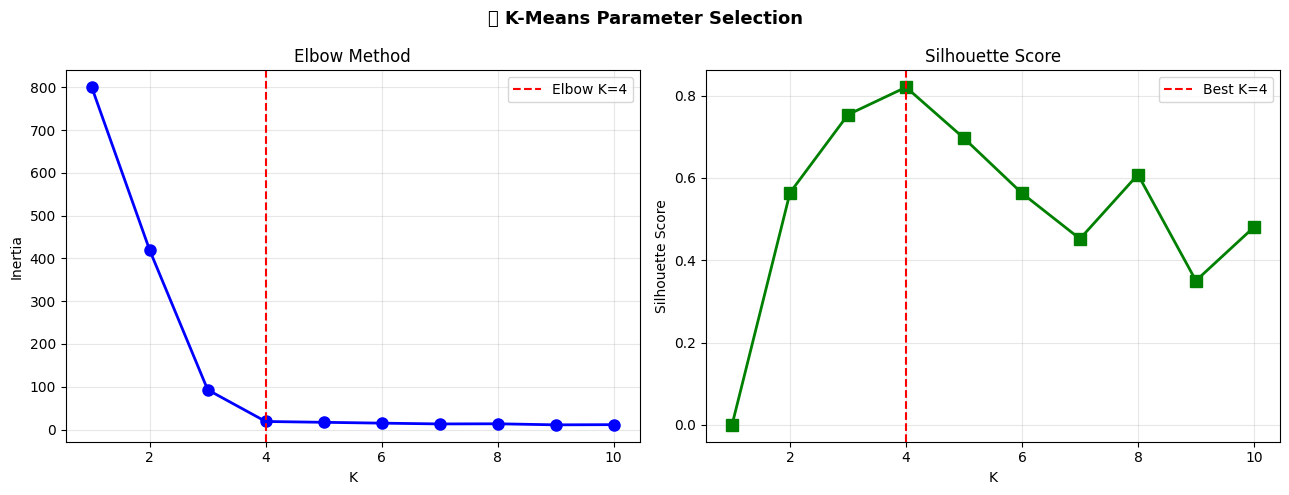


[2/4] Mean Shift...

[3/4] DBSCAN...


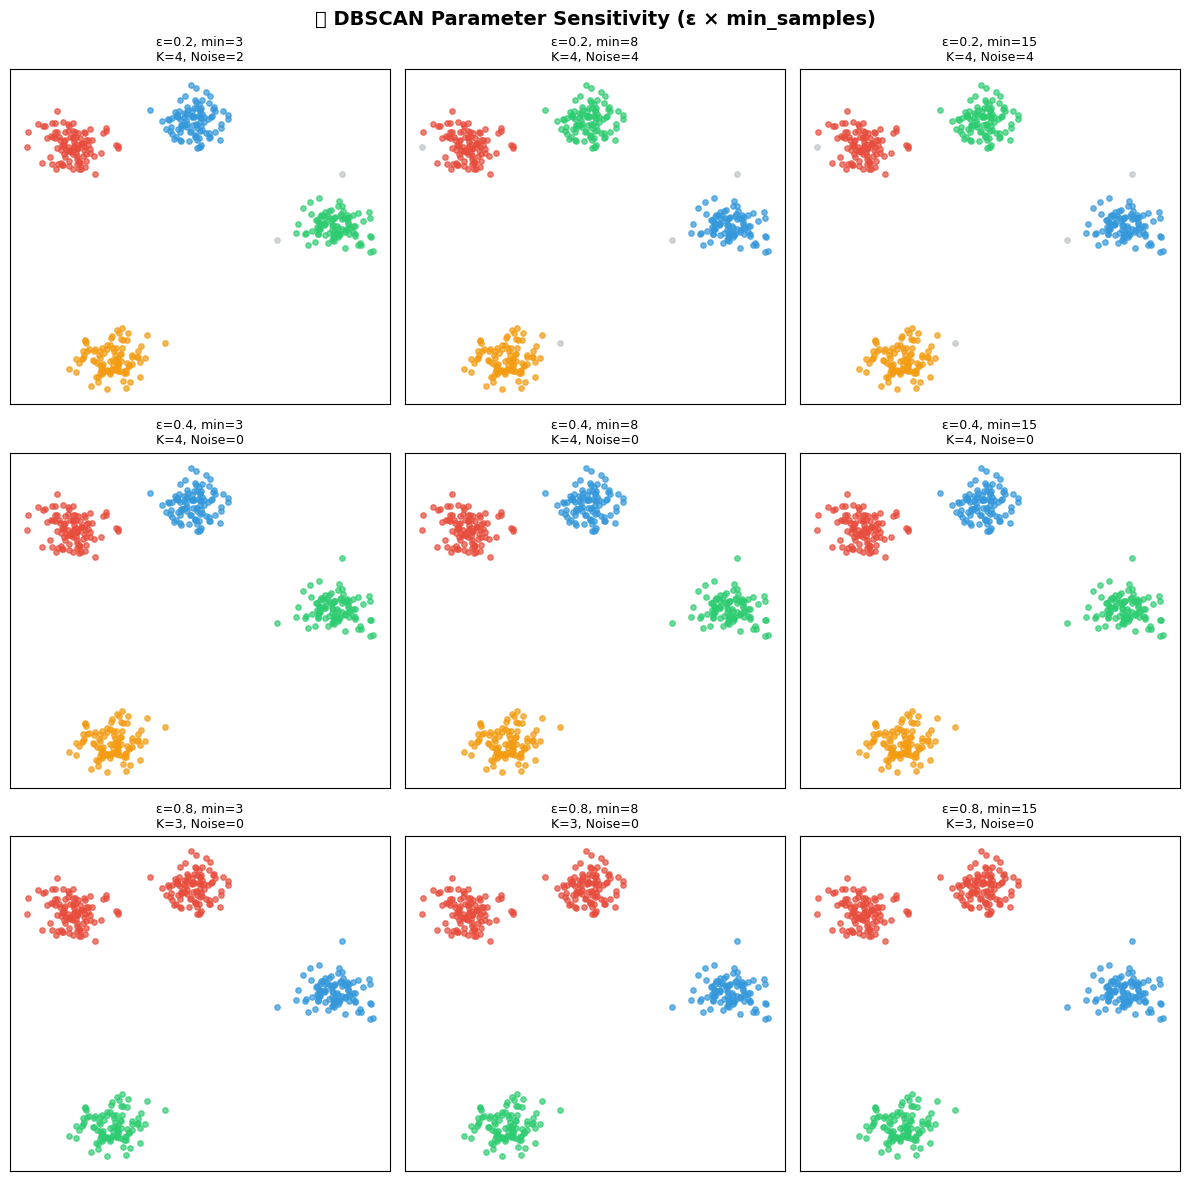


[4/4] GMM...
  [GMM] Converged at iteration 2
  [GMM] Converged at iteration 8
  [GMM] Converged at iteration 6
  [GMM] Converged at iteration 21
  [GMM] Converged at iteration 93


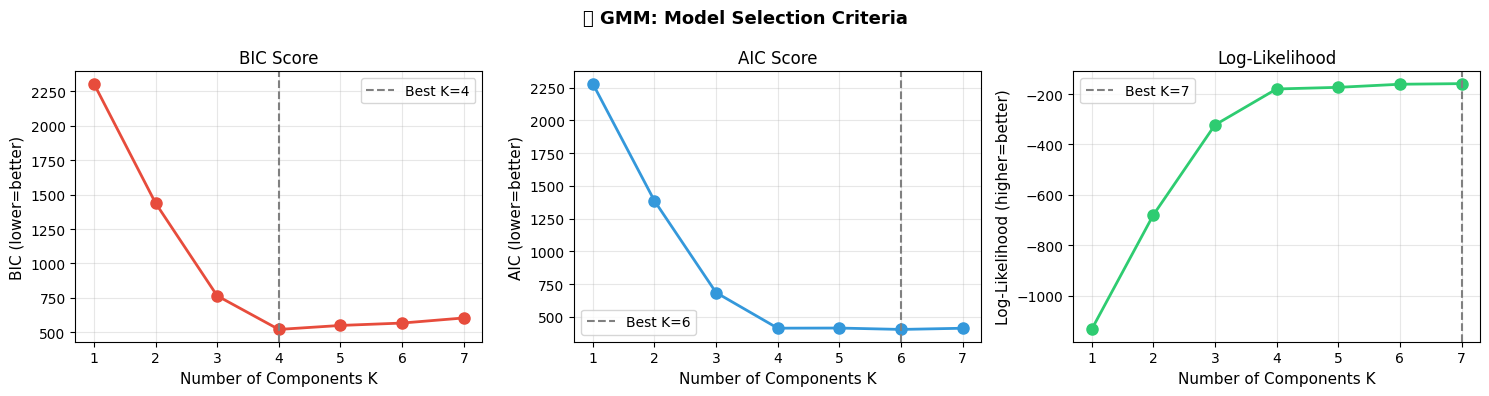

  [GMM] Converged at iteration 21


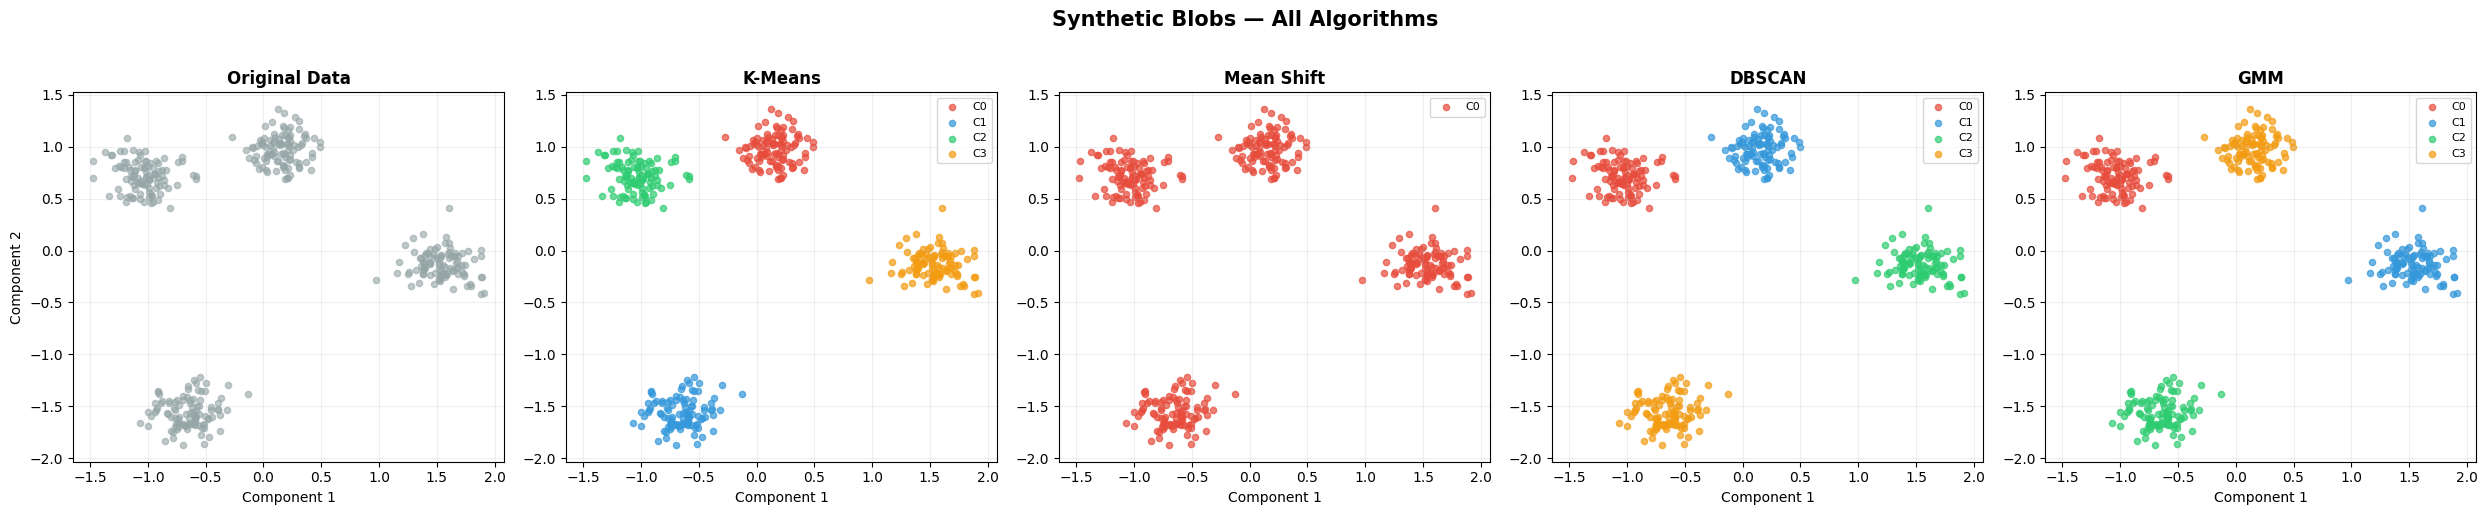


  Algorithm               K    Silhouette   Davies-Bouldin   Calinski-H
  K-Means                 4        0.8202           0.2502      5472.33
  Mean Shift            N/A             —                —            —
  DBSCAN                  4        0.8202           0.2502      5472.33
  GMM                     4        0.8202           0.2502      5472.33


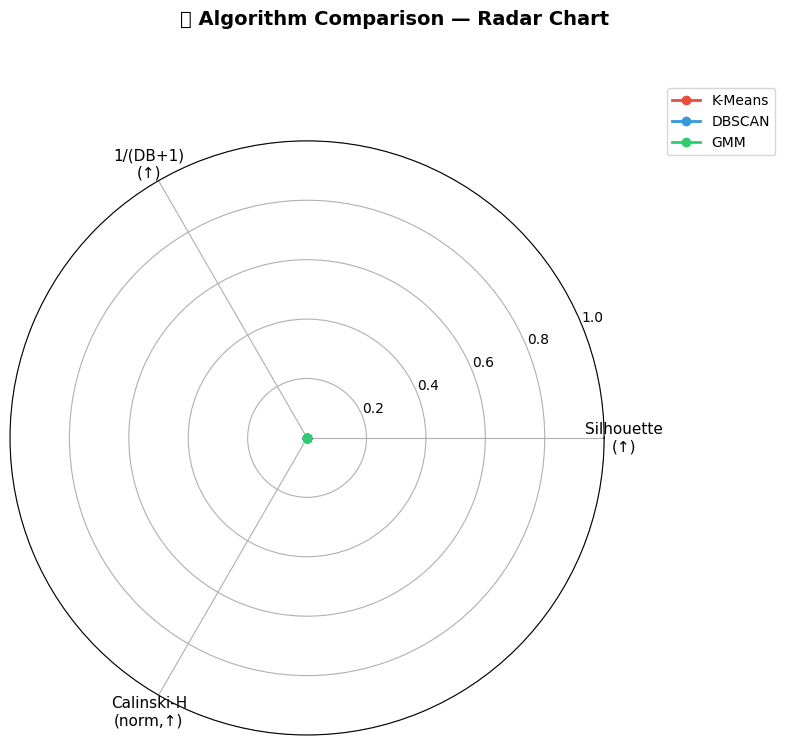


[Stress Test] Non-convex shapes...


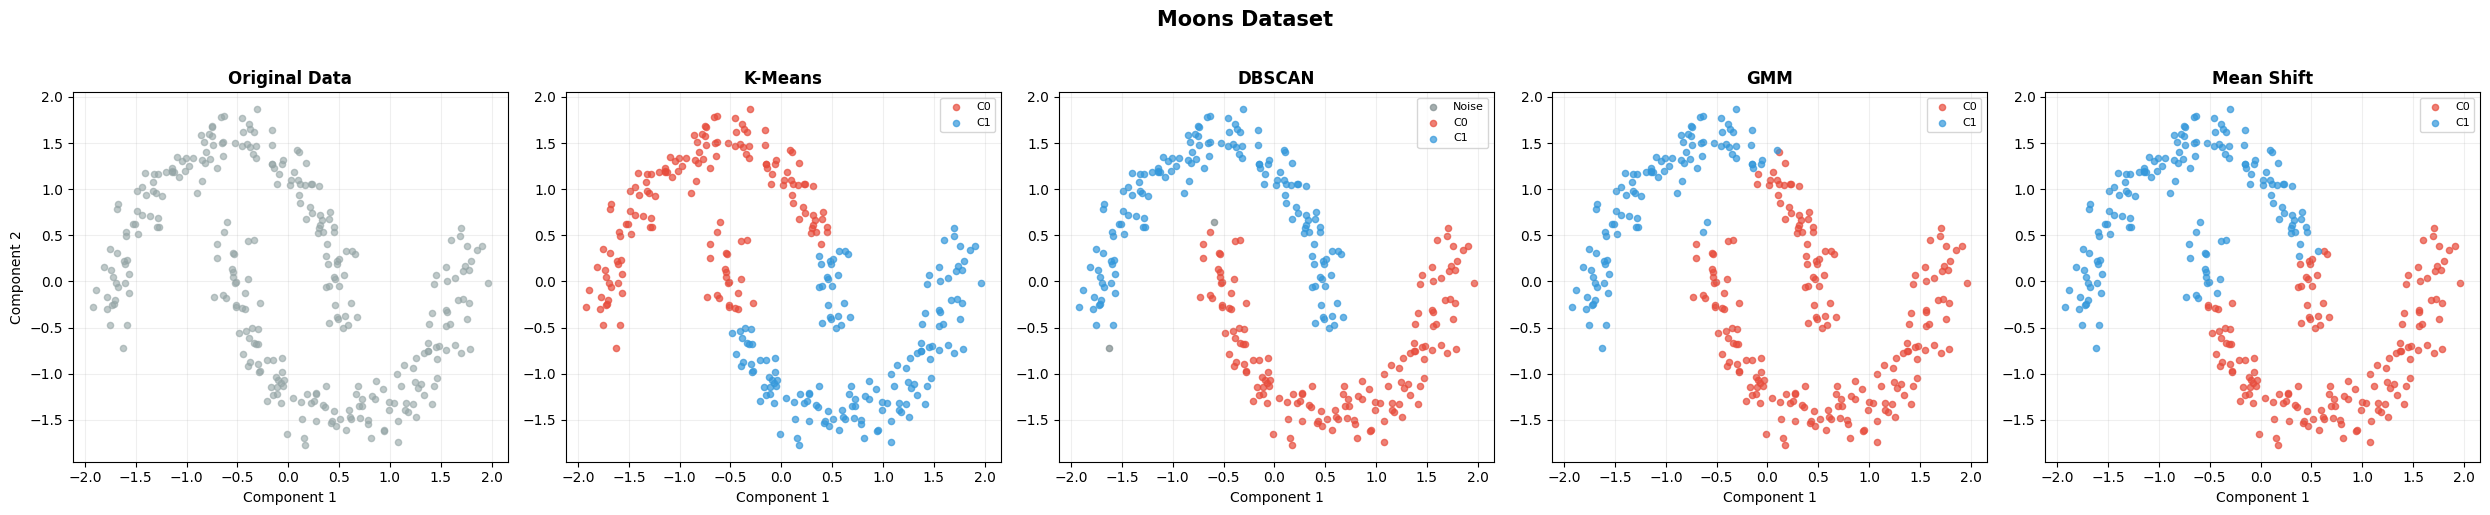

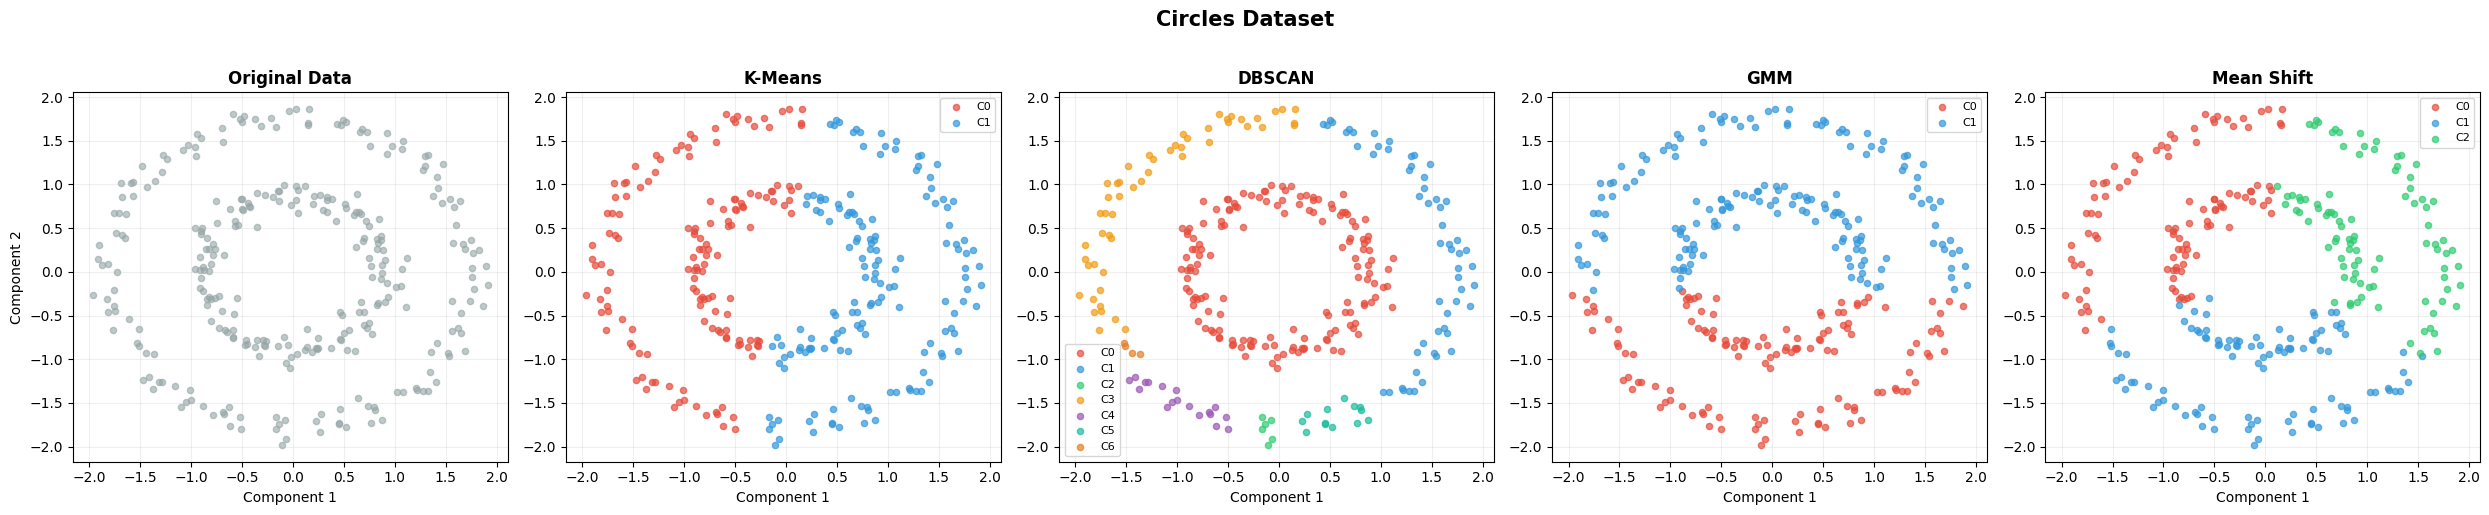


████████████████████████████████████████████████████████████
  SECTION B: REAL-WORLD — CUSTOMER SEGMENTATION
████████████████████████████████████████████████████████████

  Dataset shape : (500, 7)
  Features      : ['Age', 'Annual_Income_k', 'Spending_Score', 'Purchase_Frequency', 'Recency_Days']

  Sample rows:
      Age  Annual_Income_k  Spending_Score  Purchase_Frequency  Recency_Days         Segment_Name
48.973713       107.926035       87.181508           26.092119      4.297540 High-Value Loyalists
43.126904       133.688192       88.139478           18.122102      6.627680 High-Value Loyalists
41.292658       103.014054       83.935698           12.346879      1.000000 High-Value Loyalists
40.501700        94.807533       84.513979           16.367904      1.000000 High-Value Loyalists
56.725190       106.613355       82.540226           14.301007      3.366852 High-Value Loyalists
45.887381        92.735096       85.005584           17.597445      4.124919 High-Value Loyalist

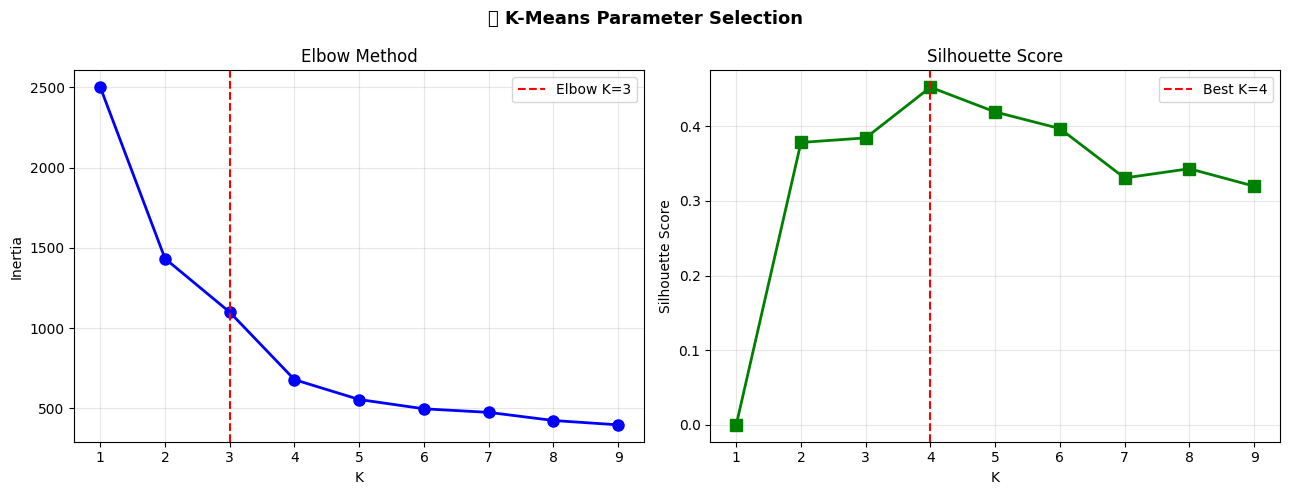


  🛍️  K-Means — Customer Segment Summary

  Segment 0  (n=98, 19.6% of customers)
  ──────────────────────────────────────────────────
    Age                      :   42.90  (±11.54)
    Annual_Income_k          :   27.98  (±7.11)
    Spending_Score           :   19.19  (±7.12)
    Purchase_Frequency       :    2.94  (±1.58)
    Recency_Days             :   44.50  (±11.63)

  Segment 1  (n=111, 22.2% of customers)
  ──────────────────────────────────────────────────
    Age                      :   50.45  (±9.64)
    Annual_Income_k          :  100.95  (±20.35)
    Spending_Score           :   20.77  (±8.97)
    Purchase_Frequency       :    5.33  (±2.27)
    Recency_Days             :   21.30  (±7.52)

  Segment 2  (n=189, 37.8% of customers)
  ──────────────────────────────────────────────────
    Age                      :   28.86  (±7.45)
    Annual_Income_k          :   44.57  (±15.51)
    Spending_Score           :   66.10  (±16.95)
    Purchase_Frequency       :   12.76  (±4.9

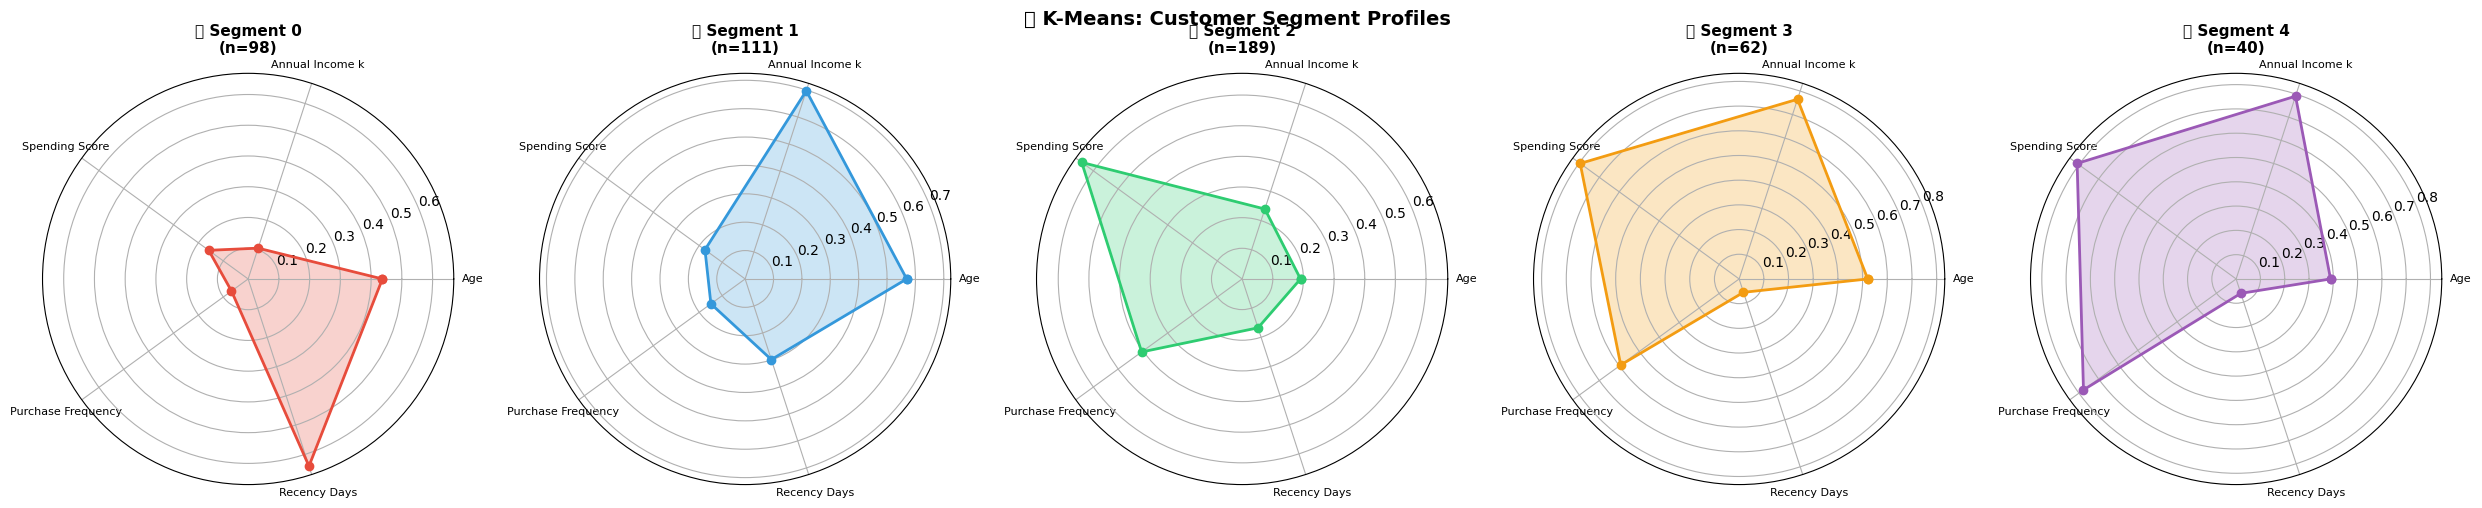


[2/4] Mean Shift on Customers...

  🛍️  Mean Shift — Customer Segment Summary

  Segment 0  (n=500, 100.0% of customers)
  ──────────────────────────────────────────────────
    Age                      :   39.64  (±12.45)
    Annual_Income_k          :   67.31  (±37.05)
    Spending_Score           :   49.86  (±28.62)
    Purchase_Frequency       :   10.72  (±7.26)
    Recency_Days             :   19.16  (±15.57)


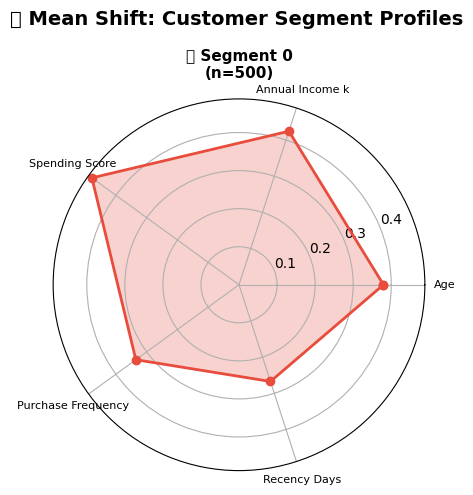


[3/4] DBSCAN on Customers...

  🛍️  DBSCAN — Customer Segment Summary

  Segment 0  (n=96, 20.9% of customers)
  ──────────────────────────────────────────────────
    Age                      :   44.45  (±6.70)
    Annual_Income_k          :  111.58  (±14.07)
    Spending_Score           :   81.30  (±7.92)
    Purchase_Frequency       :   20.38  (±3.61)
    Recency_Days             :    4.97  (±3.04)

  Segment 1  (n=274, 59.7% of customers)
  ──────────────────────────────────────────────────
    Age                      :   36.56  (±12.73)
    Annual_Income_k          :   64.77  (±32.45)
    Spending_Score           :   50.75  (±26.46)
    Purchase_Frequency       :   10.39  (±5.45)
    Recency_Days             :   15.28  (±7.92)

  Segment 2  (n=89, 19.4% of customers)
  ──────────────────────────────────────────────────
    Age                      :   42.50  (±9.68)
    Annual_Income_k          :   28.05  (±7.16)
    Spending_Score           :   18.96  (±6.99)
    Purchase_Frequ

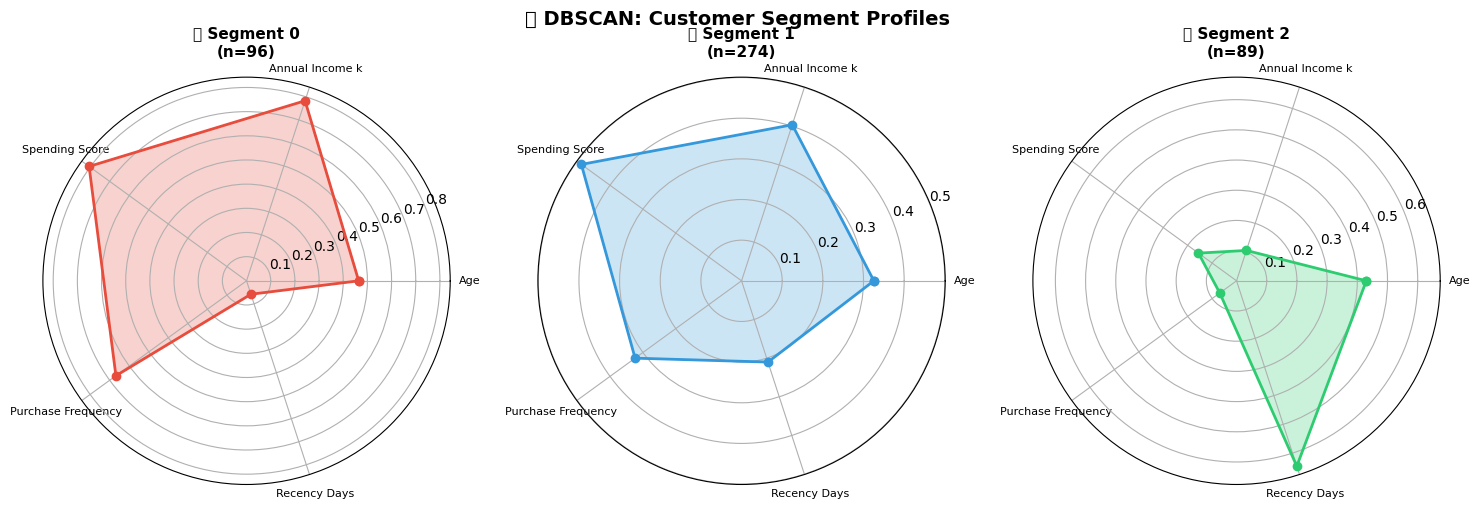


[4/4] GMM on Customers...
  [GMM] Converged at iteration 15
  [GMM] Converged at iteration 12
  [GMM] Converged at iteration 24
  [GMM] Converged at iteration 16
  [GMM] Converged at iteration 81
  [GMM] Converged at iteration 75
  [GMM] Converged at iteration 76


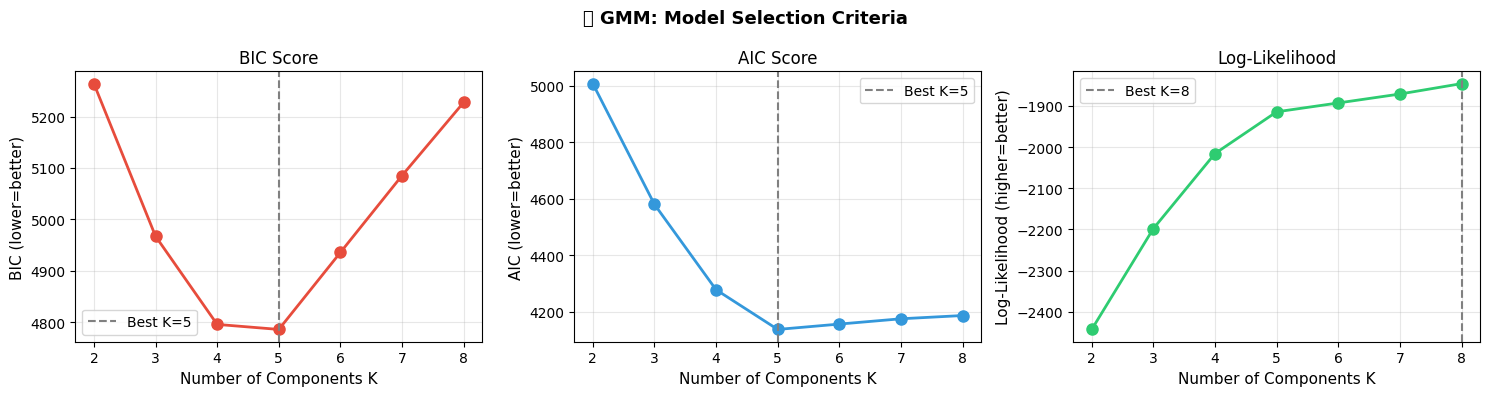

  [GMM] Converged at iteration 16

  🛍️  GMM — Customer Segment Summary

  Segment 0  (n=102, 20.4% of customers)
  ──────────────────────────────────────────────────
    Age                      :   34.64  (±9.58)
    Annual_Income_k          :   56.77  (±12.81)
    Spending_Score           :   51.71  (±12.29)
    Purchase_Frequency       :    9.73  (±3.41)
    Recency_Days             :   16.29  (±6.33)

  Segment 1  (n=101, 20.2% of customers)
  ──────────────────────────────────────────────────
    Age                      :   44.72  (±7.21)
    Annual_Income_k          :  110.89  (±14.92)
    Spending_Score           :   81.02  (±8.18)
    Purchase_Frequency       :   20.41  (±3.85)
    Recency_Days             :    4.99  (±3.03)

  Segment 2  (n=100, 20.0% of customers)
  ──────────────────────────────────────────────────
    Age                      :   43.18  (±11.82)
    Annual_Income_k          :   28.04  (±7.05)
    Spending_Score           :   19.28  (±7.15)
    Purchase_Fr

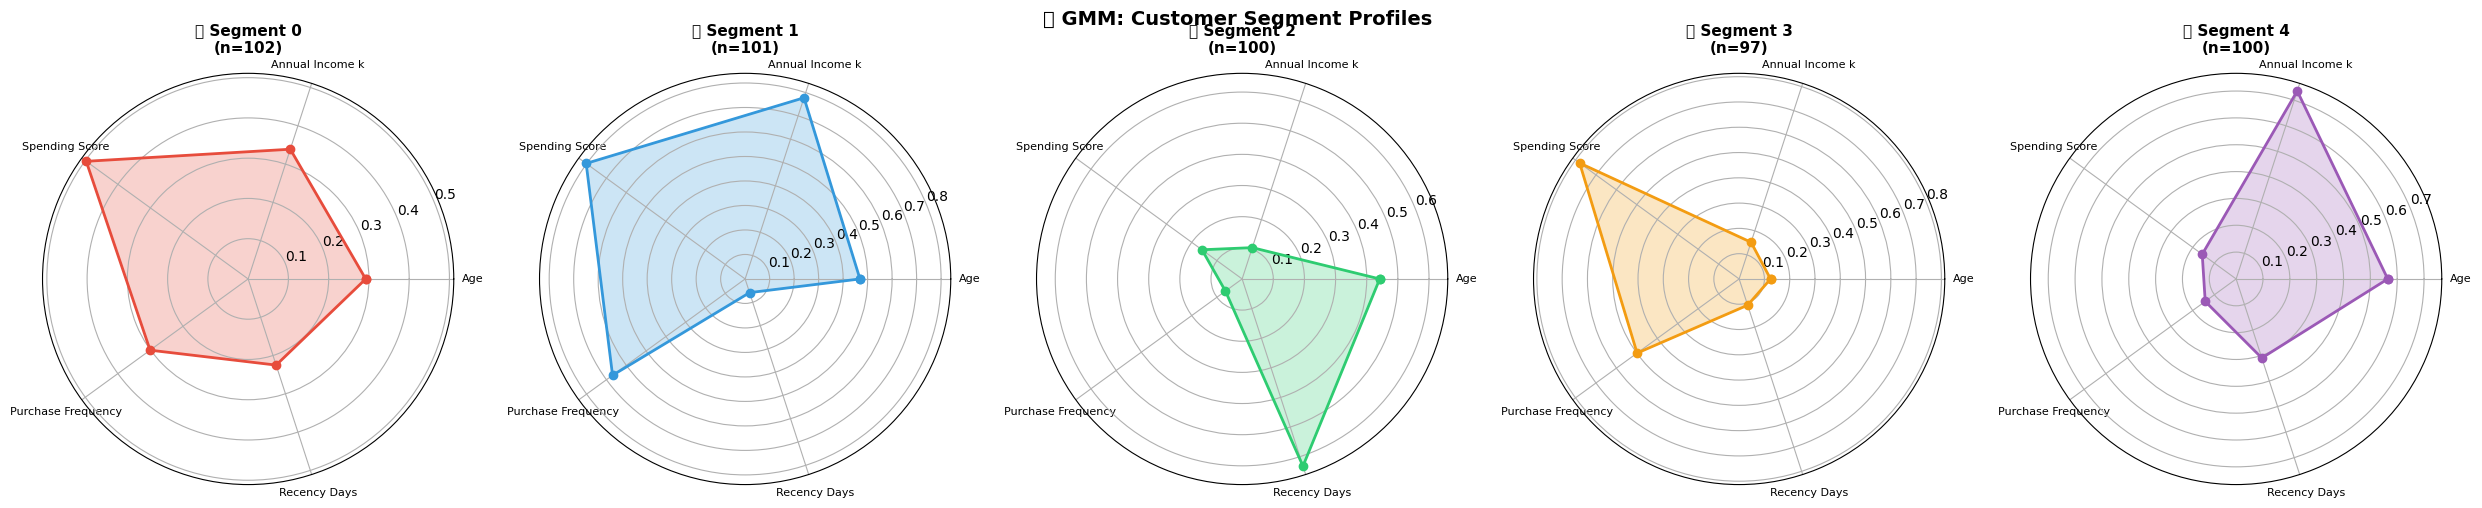

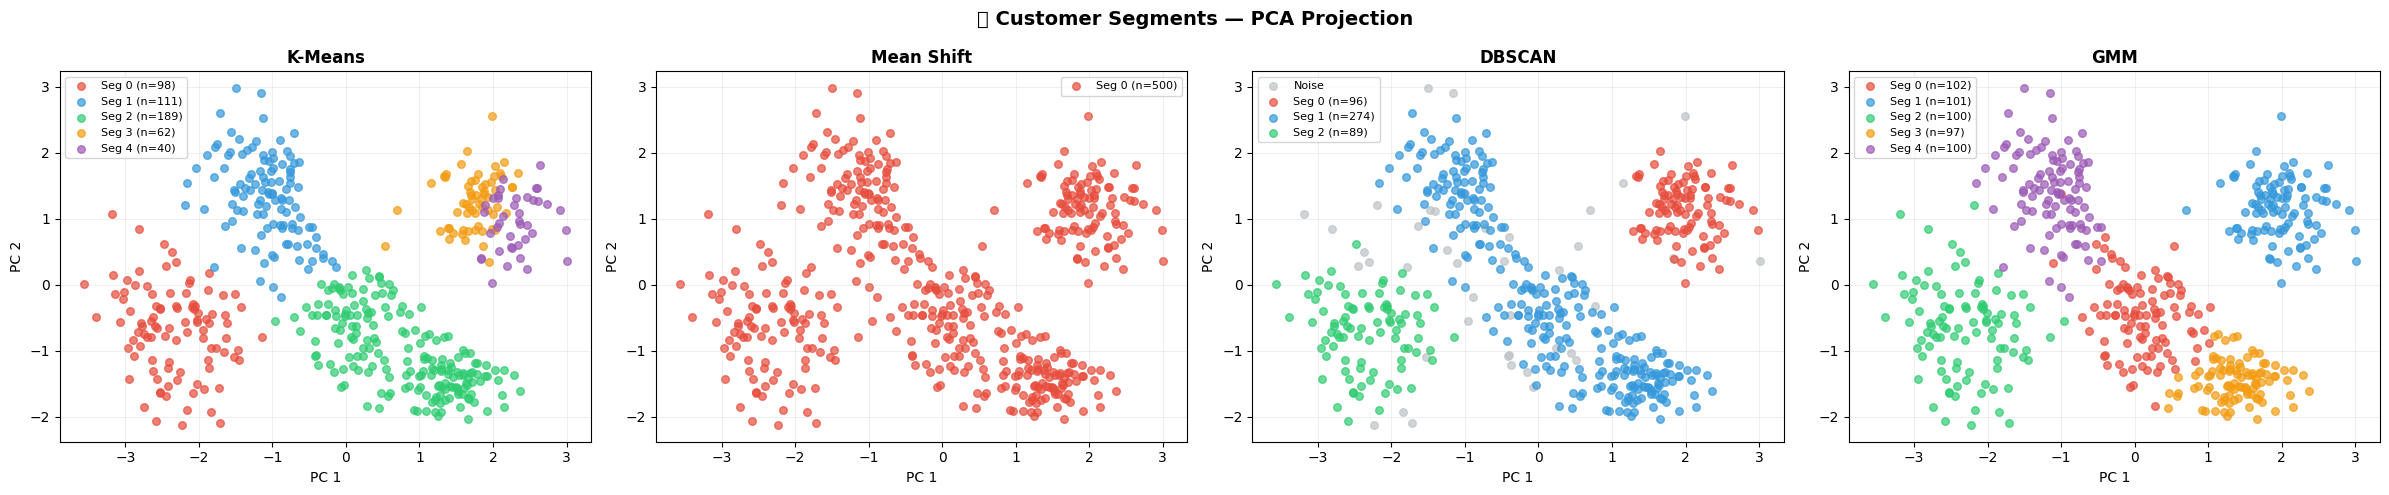


  Algorithm               K    Silhouette   Davies-Bouldin   Calinski-H
  K-Means                 5        0.3735           1.1534       346.76
  Mean Shift            N/A             —                —            —
  DBSCAN                  3        0.3331           1.0916       219.75
  GMM                     5        0.4175           0.9508       423.87


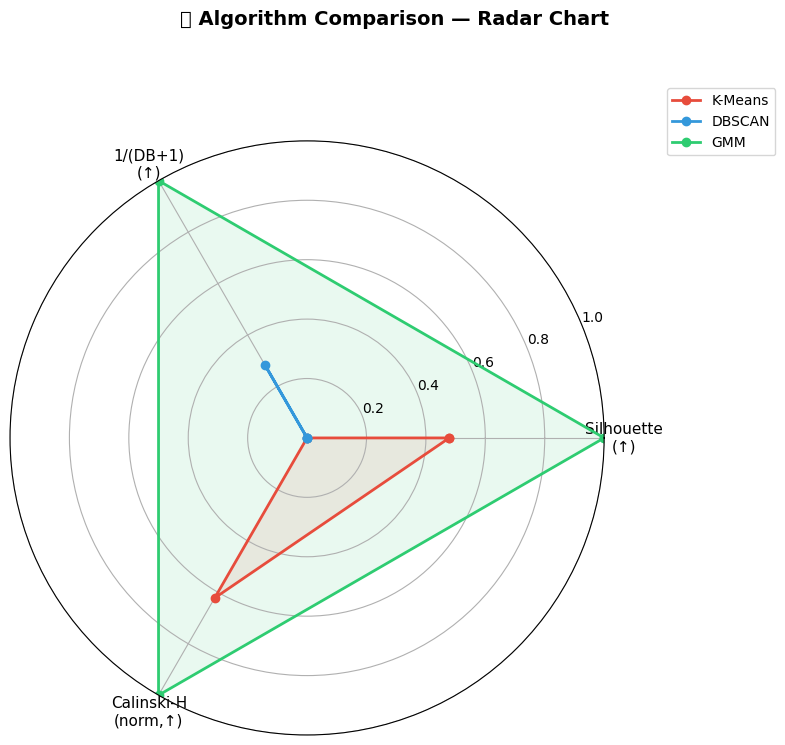


████████████████████████████████████████████████████████████

  ╔══════════════════════════════════════════════════════╗
  ║           ALGORITHM COMPARISON SUMMARY               ║
  ╠══════════════╦══════════╦═══════════╦═══════════════╣
  ║  Property    ║ K-Means  ║  DBSCAN   ║      GMM      ║
  ╠══════════════╬══════════╬═══════════╬═══════════════╣
  ║  K required  ║  YES     ║  NO       ║  YES          ║
  ║  Noise/Out.  ║  NO      ║  YES ✓    ║  NO           ║
  ║  Shape       ║  Convex  ║  Any ✓    ║  Elliptical   ║
  ║  Soft assign ║  NO      ║  NO       ║  YES ✓        ║
  ║  Speed       ║  Fast ✓  ║  Medium   ║  Medium       ║
  ║  Theory      ║  EM/opt  ║  Density  ║  Probabilistic║
  ║  Scalable    ║  YES ✓   ║  Moderate ║  Moderate     ║
  ╚══════════════╩══════════╩═══════════╩═══════════════╝
    
  ✅ Lab Complete! All plots saved as .png files.


In [20]:
# ================================================================
#   PART 9: MAIN LAB EXECUTION
# ================================================================

if __name__ == "__main__":

    # ════════════════════════════════════════════════════════
    #   SECTION A: SYNTHETIC DATASET COMPARISON
    # ════════════════════════════════════════════════════════
    print("\n" + "█"*60)
    print("  SECTION A: SYNTHETIC BENCHMARKS")
    print("█"*60)

    X_blobs, _ = make_blobs(n_samples=400, centers=4,
                             cluster_std=0.9, random_state=SEED)
    X_blobs    = StandardScaler().fit_transform(X_blobs)

    # ── K-Means ──────────────────────────────────────────────
    print("\n[1/4] K-Means...")
    plot_elbow(X_blobs)
    km = KMeans(k=4); km.fit(X_blobs)

    # ── Mean Shift ───────────────────────────────────────────
    print("\n[2/4] Mean Shift...")
    ms = MeanShift(bandwidth=1.2); ms.fit(X_blobs)

    # ── DBSCAN ───────────────────────────────────────────────
    print("\n[3/4] DBSCAN...")
    db = DBSCAN(eps=0.4, min_samples=8); db.fit(X_blobs)
    plot_dbscan_analysis(
        X_blobs,
        dbscan_model = db,
        eps_values        = [0.2, 0.4, 0.8],
        min_samples_values = [3, 8, 15],
        X = X_blobs
    )

    # ── GMM ──────────────────────────────────────────────────
    print("\n[4/4] GMM...")
    plot_gmm_selection(X_blobs, range(1, 8))
    gm = GaussianMixture(n_components=4); gm.fit(X_blobs)

    # ── All-in-one comparison ────────────────────────────────
    results_synth = {
        "K-Means"    : km.labels_,
        "Mean Shift" : ms.labels_,
        "DBSCAN"     : db.labels_,
        "GMM"        : gm.labels_,
    }
    plot_all_algorithms(X_blobs, results_synth,
                        title="Synthetic Blobs — All Algorithms")
    metrics_synth = evaluate_all(X_blobs, results_synth)
    plot_metrics_radar(metrics_synth)

    # ── Multi-shape stress test ──────────────────────────────
    print("\n[Stress Test] Non-convex shapes...")
    X_moon, _    = make_moons(n_samples=300, noise=0.08, random_state=SEED)
    X_circles, _ = make_circles(n_samples=300, noise=0.05,
                                  factor=0.5, random_state=SEED)
    for name, Xs in [("Moons", X_moon), ("Circles", X_circles)]:
        Xs = StandardScaler().fit_transform(Xs)
        km2 = KMeans(k=2);             km2.fit(Xs)
        db2 = DBSCAN(eps=0.25, min_samples=5); db2.fit(Xs)
        gm2 = GaussianMixture(n_components=2); gm2.fit(Xs)
        ms2 = MeanShift(bandwidth=0.5); ms2.fit(Xs)
        plot_all_algorithms(
            Xs,
            {"K-Means":km2.labels_,"DBSCAN":db2.labels_,
             "GMM":gm2.labels_,"Mean Shift":ms2.labels_},
            title=f"{name} Dataset"
        )

    # ════════════════════════════════════════════════════════
    #   SECTION B: CUSTOMER SEGMENTATION
    # ════════════════════════════════════════════════════════
    print("\n" + "█"*60)
    print("  SECTION B: REAL-WORLD — CUSTOMER SEGMENTATION")
    print("█"*60)

    df            = generate_customer_dataset(n=500)
    X, X_raw, features, scaler = preprocess_customers(df)

    print(f"\n  Dataset shape : {df.shape}")
    print(f"  Features      : {features}")
    print(f"\n  Sample rows:")
    print(df[features + ["Segment_Name"]].head(8).to_string(index=False))

    # PCA for 2D visualization
    pca   = PCA(n_components=2, random_state=SEED)
    X_2d  = pca.fit_transform(X)
    print(f"\n  PCA explained variance: "
          f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

    # ── Fit all algorithms ───────────────────────────────────
    print("\n[1/4] K-Means on Customers...")
    plot_elbow(X, k_range=range(1, 10))
    km_c = KMeans(k=5, init='kmeans++'); km_c.fit(X)
    print_segment_summary(df, km_c.labels_, features, "K-Means")
    plot_customer_profiles(df, km_c.labels_, "K-Means", features)

    print("\n[2/4] Mean Shift on Customers...")
    ms_c = MeanShift(bandwidth=1.5, min_freq=0.03); ms_c.fit(X)
    print_segment_summary(df, ms_c.labels_, features, "Mean Shift")
    plot_customer_profiles(df, ms_c.labels_, "Mean Shift", features)

    print("\n[3/4] DBSCAN on Customers...")
    db_c = DBSCAN(eps=0.8, min_samples=10); db_c.fit(X)
    print_segment_summary(df, db_c.labels_, features, "DBSCAN")
    plot_customer_profiles(df, db_c.labels_, "DBSCAN", features)

    print("\n[4/4] GMM on Customers...")
    plot_gmm_selection(X, range(2, 9))
    gm_c = GaussianMixture(n_components=5, max_iter=150); gm_c.fit(X)
    print_segment_summary(df, gm_c.labels_, features, "GMM")
    plot_customer_profiles(df, gm_c.labels_, "GMM", features)

    # ── Visual comparison ────────────────────────────────────
    results_cust = {
        "K-Means"    : km_c.labels_,
        "Mean Shift" : ms_c.labels_,
        "DBSCAN"     : db_c.labels_,
        "GMM"        : gm_c.labels_,
    }
    plot_customer_scatter_matrix(X_2d, results_cust, df)

    # ── Metrics ──────────────────────────────────────────────
    metrics_cust = evaluate_all(X, results_cust)
    plot_metrics_radar(metrics_cust)

    # ════════════════════════════════════════════════════════
    #   SECTION C: FINAL SUMMARY
    # ════════════════════════════════════════════════════════
    print("\n" + "█"*60)
    print("""
  ╔══════════════════════════════════════════════════════╗
  ║           ALGORITHM COMPARISON SUMMARY               ║
  ╠══════════════╦══════════╦═══════════╦═══════════════╣
  ║  Property    ║ K-Means  ║  DBSCAN   ║      GMM      ║
  ╠══════════════╬══════════╬═══════════╬═══════════════╣
  ║  K required  ║  YES     ║  NO       ║  YES          ║
  ║  Noise/Out.  ║  NO      ║  YES ✓    ║  NO           ║
  ║  Shape       ║  Convex  ║  Any ✓    ║  Elliptical   ║
  ║  Soft assign ║  NO      ║  NO       ║  YES ✓        ║
  ║  Speed       ║  Fast ✓  ║  Medium   ║  Medium       ║
  ║  Theory      ║  EM/opt  ║  Density  ║  Probabilistic║
  ║  Scalable    ║  YES ✓   ║  Moderate ║  Moderate     ║
  ╚══════════════╩══════════╩═══════════╩═══════════════╝
    """)
    print("  ✅ Lab Complete! All plots saved as .png files.")